# ColorGraph.AI Design Rating System - Research Experiment

**1. Project Overview**

This research experiment implements an automated design evaluation framework that uses state-of-the-art Vision-Language Models (VLMs) to assess visual designs according to established design principles. The system aims to provide objective, consistent ratings of design elements that closely match human expert evaluations.
Our key objectives are:

* Evaluate multiple VLM architectures for design assessment capabilities
* Compare AI evaluations with human expert annotations
* Identify which design aspects are most accurately assessed by AI models
* Create a robust, production-ready design rating system for automated feedback

# Setup and Environment

In [ ]:
!pip install -U pip
!pip install --upgrade --force-reinstall --no-cache-dir unsloth unsloth_zoo transformers accelerate bitsandbytes
!pip uninstall -y unsloth_zoo
!pip install --no-deps \
  "git+https://github.com/rupaut98/unsloth-zoo.git@fix-gemma-vision"
!pip install huggingface_hub[hf_xet] hf_xet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.7 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 220.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 202.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 357.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 286.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.2/865.2 MB 340.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 347.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 331.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 349.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 668.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 339

Found existing installation: unsloth_zoo 2025.4.3
Uninstalling unsloth_zoo-2025.4.3:
  Successfully uninstalled unsloth_zoo-2025.4.3
  Cloning https://github.com/rupaut98/unsloth-zoo.git (to revision fix-gemma-vision) to /tmp/pip-req-build-65q6e_rw
  Running command git clone --filter=blob:none --quiet https://github.com/rupaut98/unsloth-zoo.git /tmp/pip-req-build-65q6e_rw
  Running command git checkout -b fix-gemma-vision --track origin/fix-gemma-vision
  Switched to a new branch 'fix-gemma-vision'
  Branch 'fix-gemma-vision' set up to track remote branch 'fix-gemma-vision' from 'origin'.
  Resolved https://github.com/rupaut98/unsloth-zoo.git to commit 4892f36fc8d2d85313a5a0a4a5f4a5f4a2937205
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for unsloth_zoo: filename=unsloth_zoo-2025.4.1-py3-none-any.whl size=127838 sha256=dd8c29b77d11671a10e0da617ad266923de90d88eaa31deafb9e23927fc16b1

In [ ]:
!pip install llama-api-client Pillow

In [ ]:
import os
import torch
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from tqdm.notebook import tqdm
from PIL import Image
from unsloth import FastVisionModel
from unsloth import FastModel
from transformers import AutoProcessor, AutoModel, AutoTokenizer
from sklearn.metrics import mean_absolute_error
from google.colab import files, drive
from transformers import BitsAndBytesConfig
from transformers import logging as hf_logging
import gc
import time
import torchvision.transforms as T
from transformers import TextStreamer, AutoModelForCausalLM, MllamaForConditionalGeneration, AutoModelForVision2Seq
from torchvision.transforms.functional import InterpolationMode
from llama_api_client import LlamaAPIClient

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Failed to patch SmolVLMForConditionalGeneration forward function.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [ ]:
# Mount Google Drive for persistent storage
drive.mount('/content/drive')

# Create directories for results
DATA_DIR = "/content/design_data"
RESULTS_DIR = "/content/results"
VISUALIZATION_DIR = "/content/visualizations"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(VISUALIZATION_DIR, exist_ok=True)

# Global settings
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda


**Model Architecture**

We evaluate multiple Vision-Language Models (VLMs) to determine which architecture provides the most accurate and consistent design evaluations:

* Gemma-3 (Google's 12B parameter model with instruction tuning)
* Llama-3.2 (Meta's 11B Vision-Instruct model)
* InternVL3 (Open-source 14B parameter VLM)
* Qwen2.5-VL (Alibaba's 7B parameter VLM instruction model)
* Llama-4 (Meta's latest 17B model with enhanced visual capabilities)

Each model is implemented with 4-bit quantization where applicable to optimize for performance and memory usage.

# Model Handlers
We implement a flexible architecture with specialized model handlers for each VLM. Each handler manages:

* Model loading and initialization
* Input processing (text prompts and image data)
* Response generation and JSON parsing
* Cleanup and resource management

In [ ]:
class BaseModelHandler:
    """Base class for handling different VLM models"""
    def __init__(self, model_name):
        self.model_name = model_name
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        print(f"Using {self.device} for {model_name}")

    def _load_model(self):
        """To be implemented by each subclass"""
        raise NotImplementedError

    def generate_response(self, image_path, prompt):
        """To be implemented by each subclass"""
        raise NotImplementedError

    def cleanup(self):
        """Clean up resources"""
        if hasattr(self, 'model'):
            del self.model
        if hasattr(self, 'processor'):
            del self.processor
        torch.cuda.empty_cache()

# Gemma-3 model handler
class Gemma3ModelHandler(BaseModelHandler):
    """
    Vision-Language handler for Gemma-3 checkpoints served through
    Unsloth's FastVisionModel.
    """
    def __init__(self,
                 model_name: str = "unsloth/gemma-3-12b-it-bnb-4bit"):
        super().__init__(model_name)
        self._load_model()

    # ----------------------------- load ----------------------
    def _load_model(self):
        print(f"Loading Gemma-3 vision model: {self.model_name}")
        self.model, self.tokenizer = FastVisionModel.from_pretrained(
            model_name     = self.model_name,
            load_in_4bit   = True,
            max_seq_length = 2048,
        )
        FastVisionModel.for_inference(self.model)   # eval + fast KV-cache
        print("gemma-3-12b-it-bnb-4bit loaded and ready for inference")

    # -------------------------- generate ---------------------
    def generate_response(self, image_path: str, prompt: str) -> str:
        image = Image.open(image_path).convert("RGB")

        messages = [{
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": prompt},
            ],
        }]
        prompt_text = self.tokenizer.apply_chat_template(
            messages,
            add_generation_prompt = True,
            tokenize              = False,
        )

        inputs = self.tokenizer(
            image,
            prompt_text,
            add_special_tokens = False,
            return_tensors     = "pt",
        ).to(self.device)

        with torch.inference_mode():
            outputs = self.model.generate(
                **inputs,
                max_new_tokens = 2048,
                temperature    = 1.0,
                top_k          = 64,
                top_p          = 0.95,
                do_sample      = False,
                use_cache      = True,
            )

        generated_text = self.tokenizer.decode(
            outputs[0][inputs["input_ids"].shape[1]:],
            skip_special_tokens = True,
        )
        return generated_text


    def cleanup(self):
        """Clean up resources"""
        print(f"Cleaning up resources for {self.model_name}...")
        if hasattr(self, 'model'):
            print("Deleting model...")
            del self.model
        if hasattr(self, 'processor'):
            print("Deleting processor...")
            del self.processor
        print("Emptying CUDA cache...")
        torch.cuda.empty_cache()
        print("Cleanup complete.")

class Llama3ModelHandler(BaseModelHandler):
    """
    Vision-Language handler for Llama3.2-vision with enhanced error handling
    for improved JSON output adherence
    """
    def __init__(self,
                 llama_model_name="meta-llama/Llama-3.2-11B-Vision-Instruct",
                 gemma_model_name="unsloth/gemma-3-12b-it-bnb-4bit",
                 max_retries=1):
        super().__init__(llama_model_name)
        self.llama_model_name = llama_model_name
        self.gemma_model_name = gemma_model_name
        self.llama_loaded = False
        self.gemma_loaded = False
        self.max_retries = max_retries
        self._load_llama_model()

    def _load_llama_model(self):
        """Load Llama-3.2 vision model for initial evaluation"""
        print(f"Loading Llama-3.2 vision model: {self.llama_model_name}")

        q_cfg = BitsAndBytesConfig(
            load_in_4bit = True,
            bnb_4bit_use_double_quant = True,
            bnb_4bit_quant_type = "nf4",
            bnb_4bit_compute_dtype = torch.bfloat16,
        )

        self.llama_model = MllamaForConditionalGeneration.from_pretrained(
            self.llama_model_name,
            device_map="auto",
            quantization_config=q_cfg,
            torch_dtype=torch.bfloat16,
            low_cpu_mem_usage=True,
        )
        self.llama_processor = AutoProcessor.from_pretrained(self.llama_model_name)
        self.llama_loaded = True
        print(f"{self.llama_model_name} loaded and ready for inference")

    def _load_gemma_model(self):
        """Load Gemma-3 model for JSON formatting (only loaded if needed)"""
        if self.gemma_loaded:
            return

        print(f"Loading Gemma-3 model: {self.gemma_model_name}")
        self.gemma_model, self.gemma_tokenizer = FastVisionModel.from_pretrained(
            model_name=self.gemma_model_name,
            load_in_4bit=True,
            max_seq_length=2048,
        )
        FastVisionModel.for_inference(self.gemma_model)  # eval + fast KV-cache
        self.gemma_loaded = True
        print(f"{self.gemma_model_name} loaded and ready for inference")

    def generate_response(self, image_path: str, prompt: str) -> str:
        """
        Generate a design evaluation with proper JSON formatting
        using Llama-3.2 for evaluation and robust fallback mechanisms
        """
        # First attempt with regular prompt
        llama_output = self._generate_llama_response(image_path, prompt)

        # Try direct JSON parsing first
        parsed_json = None
        try:
            parsed_json = json.loads(llama_output)
            print("\nJSON parsed directly")
        except json.JSONDecodeError:
            print("\nDirect JSON parsing failed, trying extraction...")

            # Try to extract and clean JSON
            parsed_json = self._extract_clean_json(llama_output)
            if parsed_json:
                print("JSON extracted successfully")
            else:
                print("JSON extraction failed. Using Gemma3 for formatting...")

                # Load Gemma-3 model (only if needed)
                self._load_gemma_model()

                # Format the Llama3.2 output with Gemma3
                formatted_text = self._format_with_gemma(llama_output)
                try:
                    parsed_json = json.loads(formatted_text)
                    print("Gemma3 formatted JSON successfully")
                except:
                    # If Gemma3 also fails to produce valid JSON, try a retry with enhanced prompt
                    for retry in range(self.max_retries):
                        print(f"\nRetry {retry+1}/{self.max_retries} with enhanced prompt...")

                        # Enhanced prompt with stronger emphasis on structure
                        enhanced_prompt = self._create_enhanced_prompt(prompt)
                        llama_output = self._generate_llama_response(image_path, enhanced_prompt, temperature=0.2)

                        # Try parsing again
                        try:
                            parsed_json = json.loads(llama_output)
                            print(f"Retry {retry+1} succeeded with direct parsing")
                            break
                        except:
                            parsed_json = self._extract_clean_json(llama_output)
                            if parsed_json:
                                print(f"Retry {retry+1} succeeded with extraction")
                                break

                            # Final attempt with Gemma
                            if retry == self.max_retries - 1:
                                print("All retries failed. Making final attempt with Gemma...")
                                formatted_text = self._format_with_gemma(llama_output, strict_mode=True)
                                try:
                                    parsed_json = json.loads(formatted_text)
                                    print("Final Gemma3 formatting succeeded")
                                except:
                                    print("All attempts failed to produce valid JSON")

        # Validate and fill missing fields if needed
        if parsed_json:
            parsed_json = self._validate_and_fill_missing(parsed_json)
            return json.dumps(parsed_json, indent=2)
        else:
            # Create a minimal valid JSON with error flags if all else fails
            return self._create_fallback_json()

    def _generate_llama_response(self, image_path: str, prompt: str, temperature=0.5) -> str:
        """Generate the initial design evaluation using Llama-3.2"""
        image = Image.open(image_path).convert("RGB")

        messages = [{
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": prompt},
            ],
        }]

        inputs = self.llama_processor.apply_chat_template(
            messages,
            add_generation_prompt=True,
            tokenize=True,
            return_dict=True,
            return_tensors="pt",
        ).to(self.llama_model.device)

        print("\nGenerating evaluation with Llama-3.2...")
        streamer = TextStreamer(self.llama_processor.tokenizer, skip_prompt=True)
        t0 = time.time()

        with torch.inference_mode():
            out = self.llama_model.generate(
                **inputs,
                max_new_tokens=8192,
                temperature=temperature,
                do_sample=True if temperature > 0 else False,
                streamer=streamer,
                use_cache=True,
            )

        elapsed = time.time() - t0
        print(f"\nLlama-3.2 generation done in {elapsed:.1f}s")

        response = self.llama_processor.batch_decode(
            out[:, inputs["input_ids"].shape[-1]:],
            skip_special_tokens=True
        )[0]

        return response

    def _create_enhanced_prompt(self, original_prompt):
        """Create a stronger prompt that emphasizes structure and completeness"""
        enhanced_prefix = """
IMPORTANT: You must ONLY return a valid JSON object following EXACTLY the structure specified below.
Your entire response must be valid JSON with no text before or after.
You MUST include ALL categories and subcategories exactly as specified, with integer scores between 0-5 for each.
DO NOT skip any section or score, and DO NOT add any extra commentary.
I AM GOING TO DE IF YOU DON'T RETURN THE SCORES FOR EACH SUBCATEGORY. MY LIFE DEPENDS ON YOU RETURNING THE SCORES.
"""
        return enhanced_prefix + original_prompt

    def _format_with_gemma(self, llama_output: str, strict_mode=False) -> str:
        """Format Llama3.2 output into valid JSON using Gemma3"""
        prompt_prefix = "You are a JSON formatting assistant. I will provide you with the output from a design evaluation model."

        if strict_mode:
            prompt_prefix += """
This is a FINAL ATTEMPT to fix severely malformed output. Focus ONLY on creating valid JSON structure.
You MUST create a complete evaluation that follows the exact expected structure.
If information is missing, you should add placeholder values where needed.
This is critical - make your absolute best effort to produce valid, complete JSON.
"""

        prompt = f"""
{prompt_prefix}
Your task is to format this output into a valid JSON structure according to the following rules:

1. DO NOT change any content, evaluations, scores, or explanations.
2. ONLY fix JSON formatting issues, syntax errors, and structure.
3. Ensure all scores are integers between 0 and 5.
4. Keep all explanations exactly as they are.
5. Match the expected JSON structure exactly.

Here is the model output to format:

{llama_output}

The output must follow this structure:
{{
  "1. White Space Utilization": {{
    "1.1 Page Margin Assessment": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }},
    "1.2 Element Spacing": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }}
  }},
  "2. Balance Assessment": {{
    "2.1 Spatial Balance": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }},
    "2.2 Size Hierarchy": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }},
    "2.3 Typography Hierarchy": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }}
  }},
  "3. Alignment": {{
    "3.1 Element Alignment": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }},
    "3.2 Text Alignment": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }}
  }},
  "4. Typography Effectiveness": {{
    "4.1 Font Choice Appropriateness": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }},
    "4.2 Text Formatting": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }}
  }},
  "5. Color": {{
    "5.1 Color Scheme Cohesiveness": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }},
    "5.2 Color Contrast": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }},
    "5.3 Color Application": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }}
  }},
  "6. Similarity & Consistency": {{
    "6.1 Consistency in Element Types": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }},
    "6.2 Related Groups": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }}
  }},
  "7. Information Flow & Emphasis": {{
    "7.1 Hierarchical Flow & Layout Logic": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }},
    "7.2 Emphasis Techniques": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }}
  }},
  "8. Brand Adherence": {{
    "8.1 Color Brand Alignment": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }},
    "8.2 Typography Brand Alignment": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }},
    "8.3 Visual Styling Brand Alignment": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }}
  }},
  "9. Holistic Design Impact": {{
    "9.1 Visual Cohesion & Appeal": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }},
    "9.2 Communication Effectiveness": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }}
  }}
}}

Return ONLY the formatted JSON with no additional text.
"""

        messages = [{
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
            ],
        }]

        prompt_text = self.gemma_tokenizer.apply_chat_template(
            messages,
            add_generation_prompt=True,
            tokenize=False,
        )

        inputs = self.gemma_tokenizer(
            prompt_text,
            add_special_tokens=False,
            return_tensors="pt",
        ).to(self.device)

        print("\nFormatting JSON with Gemma-3...")
        t0 = time.time()

        with torch.inference_mode():
            outputs = self.gemma_model.generate(
                **inputs,
                max_new_tokens=2048,
                temperature=0.0,  # Deterministic for reliable JSON formatting
                top_k=1,
                do_sample=False,
                use_cache=True,
            )

        generated_text = self.gemma_tokenizer.decode(
            outputs[0][inputs["input_ids"].shape[1]:],
            skip_special_tokens=True,
        )

        elapsed = time.time() - t0
        print(f"JSON formatting done in {elapsed:.1f}s")

        # Try to extract clean JSON
        return self._extract_clean_json_text(generated_text)

    def _extract_clean_json(self, text):
        """Extract and clean JSON from potentially messy model output"""
        json_match = re.search(r'({[\s\S]*})', text)
        if not json_match:
            return None

        json_str = json_match.group(1)
        json_str = json_str.replace('```json', '').replace('```', '')
        json_str = re.sub(r',(\s*[}\]])', r'\1', json_str)

        try:
            parsed_json = json.loads(json_str)
            return parsed_json
        except json.JSONDecodeError as e:
            print(f"Failed to parse extracted JSON: {e}")
            return None

    def _extract_clean_json_text(self, text):
        """Extract and return clean JSON text from model output"""
        json_match = re.search(r'({[\s\S]*})', text)
        if json_match:
            json_str = json_match.group(1)
            json_str = json_str.replace('```json', '').replace('```', '')
            json_str = re.sub(r',(\s*[}\]])', r'\1', json_str)
            try:
                parsed_json = json.loads(json_str)
                return json.dumps(parsed_json, indent=2)
            except:
                pass

        # If extraction failed, return the raw output
        return text

    def _validate_and_fill_missing(self, json_obj):
        """Check for missing categories/scores and fill them if needed"""
        expected_categories = [
            "1. White Space Utilization",
            "2. Balance Assessment",
            "3. Alignment",
            "4. Typography Effectiveness",
            "5. Color",
            "6. Similarity & Consistency",
            "7. Information Flow & Emphasis",
            "8. Brand Adherence",
            "9. Holistic Design Impact"
        ]

        expected_subcategories = {
            "1. White Space Utilization": ["1.1 Page Margin Assessment", "1.2 Element Spacing"],
            "2. Balance Assessment": ["2.1 Spatial Balance", "2.2 Size Hierarchy", "2.3 Typography Hierarchy"],
            "3. Alignment": ["3.1 Element Alignment", "3.2 Text Alignment"],
            "4. Typography Effectiveness": ["4.1 Font Choice Appropriateness", "4.2 Text Formatting"],
            "5. Color": ["5.1 Color Scheme Cohesiveness", "5.2 Color Contrast", "5.3 Color Application"],
            "6. Similarity & Consistency": ["6.1 Consistency in Element Types", "6.2 Related Groups"],
            "7. Information Flow & Emphasis": ["7.1 Hierarchical Flow & Layout Logic", "7.2 Emphasis Techniques"],
            "8. Brand Adherence": ["8.1 Color Brand Alignment", "8.2 Typography Brand Alignment", "8.3 Visual Styling Brand Alignment"],
            "9. Holistic Design Impact": ["9.1 Visual Cohesion & Appeal", "9.2 Communication Effectiveness"]
        }

        # Add missing categories and subcategories
        for category in expected_categories:
            if category not in json_obj:
                json_obj[category] = {}
                print(f"Added missing category: {category}")

            for subcategory in expected_subcategories[category]:
                if subcategory not in json_obj[category]:
                    json_obj[category][subcategory] = {
                        "score": 0,
                        "explanation": "Missing evaluation. Score imputed automatically."
                    }
                    print(f"Added missing subcategory: {subcategory}")
                elif "score" not in json_obj[category][subcategory]:
                    json_obj[category][subcategory]["score"] = 0
                    print(f"Added missing score for: {subcategory}")
                elif not isinstance(json_obj[category][subcategory]["score"], int):
                    # Convert non-integer scores to integers
                    try:
                        json_obj[category][subcategory]["score"] = int(json_obj[category][subcategory]["score"])
                        print(f"Converted non-integer score for: {subcategory}")
                    except:
                        json_obj[category][subcategory]["score"] = 0
                        print(f"Invalid score format for {subcategory}, set to 0")

                # Ensure score is between 0-5
                score = json_obj[category][subcategory]["score"]
                if score < 0 or score > 5:
                    json_obj[category][subcategory]["score"] = max(0, min(5, score))
                    print(f"Clamped out-of-range score for: {subcategory}")

                # Ensure explanation exists
                if "explanation" not in json_obj[category][subcategory]:
                    json_obj[category][subcategory]["explanation"] = "No explanation provided."
                    print(f"Added missing explanation for: {subcategory}")

        return json_obj

    def _create_fallback_json(self):
        """Create a minimal valid JSON with error flags when all attempts fail"""
        fallback = {}
        expected_categories = [
            "1. White Space Utilization",
            "2. Balance Assessment",
            "3. Alignment",
            "4. Typography Effectiveness",
            "5. Color",
            "6. Similarity & Consistency",
            "7. Information Flow & Emphasis",
            "8. Brand Adherence",
            "9. Holistic Design Impact"
        ]

        expected_subcategories = {
            "1. White Space Utilization": ["1.1 Page Margin Assessment", "1.2 Element Spacing"],
            "2. Balance Assessment": ["2.1 Spatial Balance", "2.2 Size Hierarchy", "2.3 Typography Hierarchy"],
            "3. Alignment": ["3.1 Element Alignment", "3.2 Text Alignment"],
            "4. Typography Effectiveness": ["4.1 Font Choice Appropriateness", "4.2 Text Formatting"],
            "5. Color": ["5.1 Color Scheme Cohesiveness", "5.2 Color Contrast", "5.3 Color Application"],
            "6. Similarity & Consistency": ["6.1 Consistency in Element Types", "6.2 Related Groups"],
            "7. Information Flow & Emphasis": ["7.1 Hierarchical Flow & Layout Logic", "7.2 Emphasis Techniques"],
            "8. Brand Adherence": ["8.1 Color Brand Alignment", "8.2 Typography Brand Alignment", "8.3 Visual Styling Brand Alignment"],
            "9. Holistic Design Impact": ["9.1 Visual Cohesion & Appeal", "9.2 Communication Effectiveness"]
        }

        # Create minimal structure
        for category in expected_categories:
            fallback[category] = {}
            for subcategory in expected_subcategories[category]:
                fallback[category][subcategory] = {
                    "score": 0,
                    "explanation": "Error in model output. Failed to generate valid evaluation."
                }

        print("Created fallback JSON with placeholder values")
        return json.dumps(fallback, indent=2)

    def cleanup(self):
        """Clean up resources"""
        print(f"Cleaning up resources for Llama3-Gemma3 pipeline...")

        if hasattr(self, 'llama_model'):
            print("Deleting Llama model...")
            del self.llama_model

        if hasattr(self, 'llama_processor'):
            print("Deleting Llama processor...")
            del self.llama_processor

        if hasattr(self, 'gemma_model') and self.gemma_loaded:
            print("Deleting Gemma model...")
            del self.gemma_model

        if hasattr(self, 'gemma_tokenizer') and self.gemma_loaded:
            print("Deleting Gemma tokenizer...")
            del self.gemma_tokenizer

        print("Emptying CUDA cache...")
        torch.cuda.empty_cache()
        print("Cleanup complete.")

class InternVLModelHandler(BaseModelHandler):
    """
    Handler for InternVL3 Vision-Language models with Gemma3 backup for JSON formatting
    """
    def __init__(self,
                 model_name="OpenGVLab/InternVL3-14B",
                 gemma_model_name="unsloth/gemma-3-12b-it-bnb-4bit",
                 max_retries=1):
        super().__init__(model_name)
        self.model_name = model_name
        self.gemma_model_name = gemma_model_name
        self.gemma_loaded = False
        self.max_retries = max_retries
        self._load_model()

    def _load_model(self):
        """Load InternVL model and tokenizer"""
        from transformers import AutoTokenizer, AutoModel
        print(f"Loading InternVL model: {self.model_name}")

        self.tokenizer = AutoTokenizer.from_pretrained(
            self.model_name,
            trust_remote_code=True,
            use_fast=False
        )

        self.model = AutoModel.from_pretrained(
            self.model_name,
            torch_dtype=torch.bfloat16,
            low_cpu_mem_usage=True,
            trust_remote_code=True
        ).eval().to(self.device)

        print(f"{self.model_name} loaded and ready for inference")

    def _load_gemma_model(self):
        """Load Gemma-3 model for JSON formatting (only loaded if needed)"""
        if self.gemma_loaded:
            return

        from unsloth import FastVisionModel
        print(f"Loading Gemma-3 model: {self.gemma_model_name}")
        self.gemma_model, self.gemma_tokenizer = FastVisionModel.from_pretrained(
            model_name=self.gemma_model_name,
            load_in_4bit=True,
            max_seq_length=2048,
        )
        FastVisionModel.for_inference(self.gemma_model)  # eval + fast KV-cache
        self.gemma_loaded = True
        print(f"{self.gemma_model_name} loaded and ready for inference")

    def generate_response(self, image_path: str, prompt: str) -> str:
        """
        Generate a design evaluation with proper JSON formatting
        using InternVL for evaluation and Gemma-3 as backup for formatting
        """
        # First attempt with regular prompt
        internvl_output = self._generate_internvl_response(image_path, prompt)

        # Try direct JSON parsing first
        parsed_json = None
        try:
            parsed_json = json.loads(internvl_output)
            print("\nJSON parsed directly")
        except json.JSONDecodeError:
            print("\nDirect JSON parsing failed, trying extraction...")

            # Try to extract and clean JSON
            parsed_json = self._extract_clean_json(internvl_output)
            if parsed_json:
                print("JSON extracted successfully")
            else:
                print("JSON extraction failed. Using Gemma3 for formatting...")

                # Load Gemma-3 model (only if needed)
                self._load_gemma_model()

                # Format the InternVL output with Gemma3
                formatted_text = self._format_with_gemma(internvl_output)
                try:
                    parsed_json = json.loads(formatted_text)
                    print("Gemma3 formatted JSON successfully")
                except:
                    # If Gemma3 also fails to produce valid JSON, try a retry with enhanced prompt
                    for retry in range(self.max_retries):
                        print(f"\nRetry {retry+1}/{self.max_retries} with enhanced prompt...")

                        # Enhanced prompt with stronger emphasis on structure
                        enhanced_prompt = self._create_enhanced_prompt(prompt)
                        internvl_output = self._generate_internvl_response(image_path, enhanced_prompt)

                        # Try parsing again
                        try:
                            parsed_json = json.loads(internvl_output)
                            print(f"Retry {retry+1} succeeded with direct parsing")
                            break
                        except:
                            parsed_json = self._extract_clean_json(internvl_output)
                            if parsed_json:
                                print(f"Retry {retry+1} succeeded with extraction")
                                break

                            # Final attempt with Gemma
                            if retry == self.max_retries - 1:
                                print("All retries failed. Making final attempt with Gemma...")
                                formatted_text = self._format_with_gemma(internvl_output, strict_mode=True)
                                try:
                                    parsed_json = json.loads(formatted_text)
                                    print("Final Gemma3 formatting succeeded")
                                except:
                                    print("All attempts failed to produce valid JSON")

        # Validate and fill missing fields if needed
        if parsed_json:
            parsed_json = self._validate_and_fill_missing(parsed_json)
            return json.dumps(parsed_json, indent=2)
        else:
            # Create a minimal valid JSON with error flags if all else fails
            return self._create_fallback_json()

    def _generate_internvl_response(self, image_path: str, prompt: str) -> str:
        """Generate the initial design evaluation using InternVL"""
        # Process image with reduced max_num to save memory
        pixel_values = self._load_and_process_image(image_path, max_num=6)

        # Add image token to prompt if not present
        if "<image>" not in prompt:
            prompt = "<image>\n" + prompt

        try:
            print("\nGenerating evaluation with InternVL...")
            t0 = time.time()

            # Use lower max_tokens to save memory
            generation_config = dict(max_new_tokens=4096, do_sample=False)

            response = self.model.chat(
                self.tokenizer,
                pixel_values,
                prompt,
                generation_config
            )

            elapsed = time.time() - t0
            print(f"\nInternVL generation done in {elapsed:.1f}s")

            return response
        except RuntimeError as e:
            # If we encounter a memory error, try with fewer patches and tokens
            if "CUDA out of memory" in str(e):
                print("\nCUDA OOM error. Retrying with reduced resources...")
                # Reduce number of patches and tokens
                if pixel_values.size(0) > 2:
                    pixel_values = pixel_values[:2]  # Use first two patches only
                    generation_config = dict(max_new_tokens=2048, do_sample=False)
                    return self.model.chat(self.tokenizer, pixel_values, prompt, generation_config)
                elif pixel_values.size(0) > 1:
                    pixel_values = pixel_values[:1]  # Use just one patch
                    generation_config = dict(max_new_tokens=1024, do_sample=False)
                    return self.model.chat(self.tokenizer, pixel_values, prompt, generation_config)
                else:
                    # Already at minimum resources, re-raise the error
                    raise
            else:
                # Not a memory error, re-raise
                raise

    def _create_enhanced_prompt(self, original_prompt):
        """Create a stronger prompt that emphasizes structure and completeness"""
        enhanced_prefix = """
IMPORTANT: You must ONLY return a valid JSON object following EXACTLY the structure specified below.
Your entire response must be valid JSON with no text before or after.
You MUST include ALL categories and subcategories exactly as specified, with integer scores between 0-5 for each.
DO NOT skip any section or score, and DO NOT add any extra commentary.

"""
        return enhanced_prefix + original_prompt

    def _format_with_gemma(self, internvl_output: str, strict_mode=False) -> str:
        """Format InternVL output into valid JSON using Gemma3"""
        prompt_prefix = "You are a JSON formatting assistant. I will provide you with the output from a design evaluation model."

        if strict_mode:
            prompt_prefix += """
This is a FINAL ATTEMPT to fix severely malformed output. Focus ONLY on creating valid JSON structure.
You MUST create a complete evaluation that follows the exact expected structure.
If information is missing, you should add placeholder values where needed.
This is critical - make your absolute best effort to produce valid, complete JSON.
"""

        prompt = f"""
{prompt_prefix}
Your task is to format this output into a valid JSON structure according to the following rules:

1. DO NOT change any content, evaluations, scores, or explanations.
2. ONLY fix JSON formatting issues, syntax errors, and structure.
3. Ensure all scores are integers between 0 and 5.
4. Keep all explanations exactly as they are.
5. Match the expected JSON structure exactly.

Here is the model output to format:

{internvl_output}

The output must follow this structure:
{{
  "1. White Space Utilization": {{
    "1.1 Page Margin Assessment": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }},
    "1.2 Element Spacing": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }}
  }},
  "2. Balance Assessment": {{
    "2.1 Spatial Balance": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }},
    "2.2 Size Hierarchy": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }},
    "2.3 Typography Hierarchy": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }}
  }},
  "3. Alignment": {{
    "3.1 Element Alignment": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }},
    "3.2 Text Alignment": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }}
  }},
  "4. Typography Effectiveness": {{
    "4.1 Font Choice Appropriateness": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }},
    "4.2 Text Formatting": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }}
  }},
  "5. Color": {{
    "5.1 Color Scheme Cohesiveness": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }},
    "5.2 Color Contrast": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }},
    "5.3 Color Application": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }}
  }},
  "6. Similarity & Consistency": {{
    "6.1 Consistency in Element Types": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }},
    "6.2 Related Groups": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }}
  }},
  "7. Information Flow & Emphasis": {{
    "7.1 Hierarchical Flow & Layout Logic": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }},
    "7.2 Emphasis Techniques": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }}
  }},
  "8. Brand Adherence": {{
    "8.1 Color Brand Alignment": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }},
    "8.2 Typography Brand Alignment": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }},
    "8.3 Visual Styling Brand Alignment": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }}
  }},
  "9. Holistic Design Impact": {{
    "9.1 Visual Cohesion & Appeal": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }},
    "9.2 Communication Effectiveness": {{
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }}
  }}
}}

Return ONLY the formatted JSON with no additional text.
"""

        messages = [{
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
            ],
        }]

        prompt_text = self.gemma_tokenizer.apply_chat_template(
            messages,
            add_generation_prompt=True,
            tokenize=False,
        )

        inputs = self.gemma_tokenizer(
            prompt_text,
            add_special_tokens=False,
            return_tensors="pt",
        ).to(self.device)

        print("\nFormatting JSON with Gemma-3...")
        t0 = time.time()

        with torch.inference_mode():
            outputs = self.gemma_model.generate(
                **inputs,
                max_new_tokens=2048,
                temperature=0.0,  # Deterministic for reliable JSON formatting
                top_k=1,
                do_sample=False,
                use_cache=True,
            )

        generated_text = self.gemma_tokenizer.decode(
            outputs[0][inputs["input_ids"].shape[1]:],
            skip_special_tokens=True,
        )

        elapsed = time.time() - t0
        print(f"JSON formatting done in {elapsed:.1f}s")

        # Try to extract clean JSON
        return self._extract_clean_json_text(generated_text)

    def _extract_clean_json(self, text):
        """Extract and clean JSON from potentially messy model output"""
        json_match = re.search(r'({[\s\S]*})', text)
        if not json_match:
            return None

        json_str = json_match.group(1)
        json_str = json_str.replace('```json', '').replace('```', '')
        json_str = re.sub(r',(\s*[}\]])', r'\1', json_str)

        try:
            parsed_json = json.loads(json_str)
            return parsed_json
        except json.JSONDecodeError as e:
            print(f"Failed to parse extracted JSON: {e}")
            return None

    def _extract_clean_json_text(self, text):
        """Extract and return clean JSON text from model output"""
        json_match = re.search(r'({[\s\S]*})', text)
        if json_match:
            json_str = json_match.group(1)
            json_str = json_str.replace('```json', '').replace('```', '')
            json_str = re.sub(r',(\s*[}\]])', r'\1', json_str)
            try:
                parsed_json = json.loads(json_str)
                return json.dumps(parsed_json, indent=2)
            except:
                pass

        # If extraction failed, return the raw output
        return text

    def _validate_and_fill_missing(self, json_obj):
        """Check for missing categories/scores and fill them if needed"""
        expected_categories = [
            "1. White Space Utilization",
            "2. Balance Assessment",
            "3. Alignment",
            "4. Typography Effectiveness",
            "5. Color",
            "6. Similarity & Consistency",
            "7. Information Flow & Emphasis",
            "8. Brand Adherence",
            "9. Holistic Design Impact"
        ]

        expected_subcategories = {
            "1. White Space Utilization": ["1.1 Page Margin Assessment", "1.2 Element Spacing"],
            "2. Balance Assessment": ["2.1 Spatial Balance", "2.2 Size Hierarchy", "2.3 Typography Hierarchy"],
            "3. Alignment": ["3.1 Element Alignment", "3.2 Text Alignment"],
            "4. Typography Effectiveness": ["4.1 Font Choice Appropriateness", "4.2 Text Formatting"],
            "5. Color": ["5.1 Color Scheme Cohesiveness", "5.2 Color Contrast", "5.3 Color Application"],
            "6. Similarity & Consistency": ["6.1 Consistency in Element Types", "6.2 Related Groups"],
            "7. Information Flow & Emphasis": ["7.1 Hierarchical Flow & Layout Logic", "7.2 Emphasis Techniques"],
            "8. Brand Adherence": ["8.1 Color Brand Alignment", "8.2 Typography Brand Alignment", "8.3 Visual Styling Brand Alignment"],
            "9. Holistic Design Impact": ["9.1 Visual Cohesion & Appeal", "9.2 Communication Effectiveness"]
        }

        # Add missing categories and subcategories
        for category in expected_categories:
            if category not in json_obj:
                json_obj[category] = {}
                print(f"Added missing category: {category}")

            for subcategory in expected_subcategories[category]:
                if subcategory not in json_obj[category]:
                    json_obj[category][subcategory] = {
                        "score": 0,
                        "explanation": "Missing evaluation. Score imputed automatically."
                    }
                    print(f"Added missing subcategory: {subcategory}")
                elif "score" not in json_obj[category][subcategory]:
                    json_obj[category][subcategory]["score"] = 0
                    print(f"Added missing score for: {subcategory}")
                elif not isinstance(json_obj[category][subcategory]["score"], int):
                    # Convert non-integer scores to integers
                    try:
                        json_obj[category][subcategory]["score"] = int(json_obj[category][subcategory]["score"])
                        print(f"Converted non-integer score for: {subcategory}")
                    except:
                        json_obj[category][subcategory]["score"] = 0
                        print(f"Invalid score format for {subcategory}, set to 0")

                # Ensure score is between 0-5
                score = json_obj[category][subcategory]["score"]
                if score < 0 or score > 5:
                    json_obj[category][subcategory]["score"] = max(0, min(5, score))
                    print(f"Clamped out-of-range score for: {subcategory}")

                # Ensure explanation exists
                if "explanation" not in json_obj[category][subcategory]:
                    json_obj[category][subcategory]["explanation"] = "No explanation provided."
                    print(f"Added missing explanation for: {subcategory}")

        return json_obj

    def _create_fallback_json(self):
        """Create a minimal valid JSON with error flags when all attempts fail"""
        fallback = {}
        expected_categories = [
            "1. White Space Utilization",
            "2. Balance Assessment",
            "3. Alignment",
            "4. Typography Effectiveness",
            "5. Color",
            "6. Similarity & Consistency",
            "7. Information Flow & Emphasis",
            "8. Brand Adherence",
            "9. Holistic Design Impact"
        ]

        expected_subcategories = {
            "1. White Space Utilization": ["1.1 Page Margin Assessment", "1.2 Element Spacing"],
            "2. Balance Assessment": ["2.1 Spatial Balance", "2.2 Size Hierarchy", "2.3 Typography Hierarchy"],
            "3. Alignment": ["3.1 Element Alignment", "3.2 Text Alignment"],
            "4. Typography Effectiveness": ["4.1 Font Choice Appropriateness", "4.2 Text Formatting"],
            "5. Color": ["5.1 Color Scheme Cohesiveness", "5.2 Color Contrast", "5.3 Color Application"],
            "6. Similarity & Consistency": ["6.1 Consistency in Element Types", "6.2 Related Groups"],
            "7. Information Flow & Emphasis": ["7.1 Hierarchical Flow & Layout Logic", "7.2 Emphasis Techniques"],
            "8. Brand Adherence": ["8.1 Color Brand Alignment", "8.2 Typography Brand Alignment", "8.3 Visual Styling Brand Alignment"],
            "9. Holistic Design Impact": ["9.1 Visual Cohesion & Appeal", "9.2 Communication Effectiveness"]
        }

        # Create minimal structure
        for category in expected_categories:
            fallback[category] = {}
            for subcategory in expected_subcategories[category]:
                fallback[category][subcategory] = {
                    "score": 0,
                    "explanation": "Error in model output. Failed to generate valid evaluation."
                }

        print("Created fallback JSON with placeholder values")
        return json.dumps(fallback, indent=2)

    def _load_and_process_image(self, image_path: str, max_num=6):
        """
        Load and process an image for the model
        Args:
            image_path (str): Path to the image
            max_num (int): Maximum number of image patches
        Returns:
            torch.Tensor: Processed image tensor
        """
        from PIL import Image
        import torchvision.transforms as T
        from torchvision.transforms.functional import InterpolationMode

        IMAGENET_MEAN = (0.485, 0.456, 0.406)
        IMAGENET_STD = (0.229, 0.224, 0.225)

        def build_transform(input_size):
            transform = T.Compose([
                T.Lambda(lambda img: img.convert('RGB') if img.mode != 'RGB' else img),
                T.Resize((input_size, input_size), interpolation=InterpolationMode.BICUBIC),
                T.ToTensor(),
                T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
            ])
            return transform

        def find_closest_aspect_ratio(aspect_ratio, target_ratios, width, height, image_size):
            best_ratio_diff = float('inf')
            best_ratio = (1, 1)
            area = width * height
            for ratio in target_ratios:
                target_aspect_ratio = ratio[0] / ratio[1]
                ratio_diff = abs(aspect_ratio - target_aspect_ratio)
                if ratio_diff < best_ratio_diff:
                    best_ratio_diff = ratio_diff
                    best_ratio = ratio
                elif ratio_diff == best_ratio_diff:
                    if area > 0.5 * image_size * image_size * ratio[0] * ratio[1]:
                        best_ratio = ratio
            return best_ratio

        def dynamic_preprocess(image, min_num=1, max_num=6, image_size=448, use_thumbnail=False):
            orig_width, orig_height = image.size
            aspect_ratio = orig_width / orig_height

            # Calculate the existing image aspect ratio
            target_ratios = set(
                (i, j) for n in range(min_num, max_num + 1) for i in range(1, n + 1) for j in range(1, n + 1) if
                i * j <= max_num and i * j >= min_num)
            target_ratios = sorted(target_ratios, key=lambda x: x[0] * x[1])

            # Find the closest aspect ratio to the target
            target_aspect_ratio = find_closest_aspect_ratio(
                aspect_ratio, target_ratios, orig_width, orig_height, image_size)

            # Calculate the target width and height
            target_width = image_size * target_aspect_ratio[0]
            target_height = image_size * target_aspect_ratio[1]
            blocks = target_aspect_ratio[0] * target_aspect_ratio[1]

            # Resize the image
            resized_img = image.resize((target_width, target_height))
            processed_images = []
            for i in range(blocks):
                box = (
                    (i % (target_width // image_size)) * image_size,
                    (i // (target_width // image_size)) * image_size,
                    ((i % (target_width // image_size)) + 1) * image_size,
                    ((i // (target_width // image_size)) + 1) * image_size
                )
                # Split the image
                split_img = resized_img.crop(box)
                processed_images.append(split_img)

            if use_thumbnail and len(processed_images) != 1:
                thumbnail_img = image.resize((image_size, image_size))
                processed_images.append(thumbnail_img)
            return processed_images

        # Load and process the image
        image = Image.open(image_path).convert('RGB')
        transform = build_transform(input_size=448)
        images = dynamic_preprocess(image, image_size=448, use_thumbnail=True, max_num=max_num)

        # Limit to a maximum of 'max_num' patches to control memory usage
        if len(images) > max_num:
            images = images[:max_num]

        pixel_values = [transform(image) for image in images]
        pixel_values = torch.stack(pixel_values).to(torch.bfloat16).to(self.device)

        return pixel_values

    def cleanup(self):
        """Clean up resources"""
        print(f"Cleaning up resources for {self.model_name}...")
        if hasattr(self, 'model'):
            print("Deleting model...")
            del self.model
        if hasattr(self, 'tokenizer'):
            print("Deleting tokenizer...")
            del self.tokenizer
        if hasattr(self, 'gemma_model') and self.gemma_loaded:
            print("Deleting Gemma model...")
            del self.gemma_model
        if hasattr(self, 'gemma_tokenizer') and self.gemma_loaded:
            print("Deleting Gemma tokenizer...")
            del self.gemma_tokenizer
        print("Emptying CUDA cache...")
        torch.cuda.empty_cache()
        print("Cleanup complete.")

# Gemma-3 model handler
class Gemma3ModelHandler(BaseModelHandler):
    """
    Vision-Language handler for Gemma-3 checkpoints served through
    Unsloth's FastVisionModel.
    """
    def __init__(self,
                 model_name: str = "unsloth/gemma-3-12b-it-bnb-4bit"):
        super().__init__(model_name)
        self._load_model()

    # ----------------------------- load ----------------------
    def _load_model(self):
        print(f"Loading Gemma-3 vision model: {self.model_name}")
        self.model, self.tokenizer = FastVisionModel.from_pretrained(
            model_name     = self.model_name,
            load_in_4bit   = True,
            max_seq_length = 2048,
        )
        FastVisionModel.for_inference(self.model)   # eval + fast KV-cache
        print("gemma-3-12b-it-bnb-4bit loaded and ready for inference")

    # -------------------------- generate ---------------------
    def generate_response(self, image_path: str, prompt: str) -> str:
        image = Image.open(image_path).convert("RGB")

        messages = [{
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": prompt},
            ],
        }]
        prompt_text = self.tokenizer.apply_chat_template(
            messages,
            add_generation_prompt = True,
            tokenize              = False,
        )

        inputs = self.tokenizer(
            image,
            prompt_text,
            add_special_tokens = False,
            return_tensors     = "pt",
        ).to(self.device)

        with torch.inference_mode():
            outputs = self.model.generate(
                **inputs,
                max_new_tokens = 2048,
                temperature    = 1.0,
                top_k          = 64,
                top_p          = 0.95,
                do_sample      = False,
                use_cache      = True,
            )

        generated_text = self.tokenizer.decode(
            outputs[0][inputs["input_ids"].shape[1]:],
            skip_special_tokens = True,
        )
        return generated_text


    def cleanup(self):
        """Clean up resources"""
        print(f"Cleaning up resources for {self.model_name}...")
        if hasattr(self, 'model'):
            print("Deleting model...")
            del self.model
        if hasattr(self, 'processor'):
            print("Deleting processor...")
            del self.processor
        print("Emptying CUDA cache...")
        torch.cuda.empty_cache()
        print("Cleanup complete.")

# Qwen 2.5-VL model handler
class QwenModelHandler(BaseModelHandler):
    """
    Vision-Language handler for Qwen 2.5-VL checkpoints served through
    Unsloth's FastVisionModel.
    """
    def __init__(self,
                 model_name: str = "unsloth/Qwen2.5-VL-7B-Instruct-unsloth-bnb-4bit"):
        super().__init__(model_name)
        self._load_model()

    # ----------------------------- load ----------------------
    def _load_model(self):
        print(f"Loading Qwen 2.5-VL vision model: {self.model_name}")
        self.model, self.tokenizer = FastVisionModel.from_pretrained(
            model_name     = self.model_name,
            load_in_4bit   = True,
            max_seq_length = 2048,
        )
        FastVisionModel.for_inference(self.model)   # eval + fast KV-cache
        print("unsloth/Qwen2.5-VL-7B-Instruct-unsloth-bnb-4bit loaded and ready for inference")

    # -------------------------- generate ---------------------
    def generate_response(self, image_path: str, prompt: str) -> str:
        image = Image.open(image_path).convert("RGB")

        messages = [{
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": prompt},
            ],
        }]
        prompt_text = self.tokenizer.apply_chat_template(
            messages,
            add_generation_prompt = True,
            tokenize              = False,
        )

        inputs = self.tokenizer(
            image,
            prompt_text,
            add_special_tokens = False,
            return_tensors     = "pt",
        ).to(self.device)

        with torch.inference_mode():
            outputs = self.model.generate(
                **inputs,
                max_new_tokens = 2048,
                temperature    = 1.0,
                top_k          = 64,
                top_p          = 0.95,
                do_sample      = False,
                use_cache      = True,
            )

        generated_text = self.tokenizer.decode(
            outputs[0][inputs["input_ids"].shape[1]:],
            skip_special_tokens = True,
        )
        return generated_text


    def cleanup(self):
        """Clean up resources"""
        print(f"Cleaning up resources for {self.model_name}...")
        if hasattr(self, 'model'):
            print("Deleting model...")
            del self.model
        if hasattr(self, 'processor'):
            print("Deleting processor...")
            del self.processor
        print("Emptying CUDA cache...")
        torch.cuda.empty_cache()
        print("Cleanup complete.")

class Llama4ModelHandler(BaseModelHandler):
    """
    Vision-Language handler for Llama 4 models via the Llama API
    """
    def __init__(self,
                model_name="Llama-4-Scout-17B-16E-Instruct-FP8",
                max_retries=1):
        super().__init__(model_name)
        self.model_name = model_name
        self.max_retries = max_retries
        self._load_model()

    def _load_model(self):
        """Load Llama API client for Llama 4"""
        from llama_api_client import LlamaAPIClient

        print(f"Setting up Llama 4 API client for model: {self.model_name}")

        # Initialize API client with hardcoded API key
        self.client = LlamaAPIClient(
            api_key="LLM|775050591534730|mY_Kl-PQZm9APXjhZCQlLgnSbLs",
            base_url="https://api.llama.com/v1/",
        )
        print(f"{self.model_name} API client ready for inference")

    def generate_response(self, image_path: str, prompt: str) -> str:
        """
        Generate a design evaluation with proper JSON formatting using Llama 4
        """
        # Generate initial evaluation using Llama 4
        llama_output = self._generate_llama4_response(image_path, prompt)

        # Try direct JSON parsing first
        parsed_json = None
        try:
            parsed_json = json.loads(llama_output)
            print("\nJSON parsed directly")
        except json.JSONDecodeError:
            print("\nDirect JSON parsing failed, trying extraction...")
            # Try to extract and clean JSON
            parsed_json = self._extract_clean_json(llama_output)
            if parsed_json:
                print("JSON extracted successfully")
            else:
                # If extraction fails, try a retry with enhanced prompt
                for retry in range(self.max_retries):
                    print(f"\nRetry {retry+1}/{self.max_retries} with enhanced prompt")
                    # Enhanced prompt with stronger emphasis on structure
                    enhanced_prompt = self._create_enhanced_prompt(prompt)
                    llama_output = self._generate_llama4_response(image_path, enhanced_prompt)
                    # Try parsing again
                    try:
                        parsed_json = json.loads(llama_output)
                        print(f"Retry {retry+1} succeeded with direct parsing")
                        break
                    except:
                        parsed_json = self._extract_clean_json(llama_output)
                        if parsed_json:
                            print(f"Retry {retry+1} succeeded with extraction")
                            break

        # Validate and fill missing fields if needed
        if parsed_json:
            parsed_json = self._validate_and_fill_missing(parsed_json)
            return json.dumps(parsed_json, indent=2)
        else:
            # Create a minimal valid JSON with error flags if all else fails
            return self._create_fallback_json()

    def _generate_llama4_response(self, image_path: str, prompt: str, temperature=0.6) -> str:
        """Generate the initial design evaluation using Llama 4"""
        import base64
        from PIL import Image
        import io

        # Load and convert image to base64
        print("\nProcessing image for Llama 4 API...")
        image = Image.open(image_path).convert("RGB")
        buffered = io.BytesIO()
        image.save(buffered, format="JPEG")
        img_str = base64.b64encode(buffered.getvalue()).decode("utf-8")

        # Build message with image
        print("\nGenerating evaluation with Llama 4...")
        import time
        t0 = time.time()

        try:
            response = self.client.chat.completions.create(
                model=self.model_name,
                messages=[
                    {
                        "role": "user",
                        "content": [
                            {
                                "type": "text",
                                "text": prompt,
                            },
                            {
                                "type": "image_url",
                                "image_url": {
                                    "url": f"data:image/jpeg;base64,{img_str}",
                                },
                            },
                        ],
                    },
                ],
                temperature=temperature,
                max_completion_tokens=4096,
            )

            elapsed = time.time() - t0
            print(f"\nLlama 4 generation done in {elapsed:.1f}s")

            # Extract and return the text content
            return response.completion_message.content.text

        except Exception as e:
            print(f"Error during Llama 4 API call: {str(e)}")
            # Return error message in a format that can be handled downstream
            return f"{{\"error\": \"Llama 4 API error: {str(e)}\"}}"

    def _create_enhanced_prompt(self, original_prompt):
        """Create a stronger prompt that emphasizes structure and completeness"""
        enhanced_prefix = """
        IMPORTANT: You must ONLY return a valid JSON object following EXACTLY the structure provided.
        Your entire response must be valid JSON with no text before or after.
        You MUST include ALL categories and subcategories exactly as specified, with integer scores from 0-5.
        DO NOT skip any section or score, and DO NOT add any extra commentary.
        This is critical - ONLY return the JSON formatted response.
        """
        return enhanced_prefix + original_prompt

    def _extract_clean_json(self, text):
        """Extract and clean JSON from potentially messy model output"""
        json_match = re.search(r'({[\s\S]*})', text)
        if not json_match:
            return None

        json_str = json_match.group(1)
        json_str = json_str.replace('```json', '').replace('```', '')
        json_str = re.sub(r',(\s*[}\]])', r'\1', json_str)

        try:
            parsed_json = json.loads(json_str)
            return parsed_json
        except json.JSONDecodeError as e:
            print(f"Failed to parse extracted JSON: {e}")
            return None

    def _validate_and_fill_missing(self, json_obj):
        """Check for missing categories/scores and fill them if needed"""
        expected_categories = [
            "1. White Space Utilization",
            "2. Balance Assessment",
            "3. Alignment",
            "4. Typography Effectiveness",
            "5. Color",
            "6. Similarity & Consistency",
            "7. Information Flow & Emphasis",
            "8. Brand Adherence",
            "9. Holistic Design Impact"
        ]

        expected_subcategories = {
            "1. White Space Utilization": ["1.1 Page Margin Assessment", "1.2 Element Spacing"],
            "2. Balance Assessment": ["2.1 Spatial Balance", "2.2 Size Hierarchy", "2.3 Typography Hierarchy"],
            "3. Alignment": ["3.1 Element Alignment", "3.2 Text Alignment"],
            "4. Typography Effectiveness": ["4.1 Font Choice Appropriateness", "4.2 Text Formatting"],
            "5. Color": ["5.1 Color Scheme Cohesiveness", "5.2 Color Contrast", "5.3 Color Application"],
            "6. Similarity & Consistency": ["6.1 Consistency in Element Types", "6.2 Related Groups"],
            "7. Information Flow & Emphasis": ["7.1 Hierarchical Flow & Layout Logic", "7.2 Emphasis Techniques"],
            "8. Brand Adherence": ["8.1 Color Brand Alignment", "8.2 Typography Brand Alignment", "8.3 Visual Styling Brand Alignment"],
            "9. Holistic Design Impact": ["9.1 Visual Cohesion & Appeal", "9.2 Communication Effectiveness"]
        }

        # Add missing categories and subcategories
        for category in expected_categories:
            if category not in json_obj:
                json_obj[category] = {}
                print(f"Added missing category: {category}")

            for subcategory in expected_subcategories[category]:
                if subcategory not in json_obj[category]:
                    json_obj[category][subcategory] = {
                        "score": 0,
                        "explanation": "Missing evaluation. Score imputed automatically."
                    }
                    print(f"Added missing subcategory: {subcategory}")
                elif "score" not in json_obj[category][subcategory]:
                    json_obj[category][subcategory]["score"] = 0
                    print(f"Added missing score for: {subcategory}")
                elif not isinstance(json_obj[category][subcategory]["score"], int):
                    # Convert non-integer scores to integers
                    try:
                        json_obj[category][subcategory]["score"] = int(json_obj[category][subcategory]["score"])
                        print(f"Converted non-integer score for: {subcategory}")
                    except:
                        json_obj[category][subcategory]["score"] = 0
                        print(f"Invalid score format for {subcategory}, set to 0")

                # Ensure score is between 0-5
                score = json_obj[category][subcategory]["score"]
                if score < 0 or score > 5:
                    json_obj[category][subcategory]["score"] = max(0, min(5, score))
                    print(f"Clamped out-of-range score for: {subcategory}")

                # Ensure explanation exists
                if "explanation" not in json_obj[category][subcategory]:
                    json_obj[category][subcategory]["explanation"] = "No explanation provided."
                    print(f"Added missing explanation for: {subcategory}")

        return json_obj

    def _create_fallback_json(self):
        """Create a minimal valid JSON with error flags when all attempts fail"""
        fallback = {}
        expected_categories = [
            "1. White Space Utilization",
            "2. Balance Assessment",
            "3. Alignment",
            "4. Typography Effectiveness",
            "5. Color",
            "6. Similarity & Consistency",
            "7. Information Flow & Emphasis",
            "8. Brand Adherence",
            "9. Holistic Design Impact"
        ]

        expected_subcategories = {
            "1. White Space Utilization": ["1.1 Page Margin Assessment", "1.2 Element Spacing"],
            "2. Balance Assessment": ["2.1 Spatial Balance", "2.2 Size Hierarchy", "2.3 Typography Hierarchy"],
            "3. Alignment": ["3.1 Element Alignment", "3.2 Text Alignment"],
            "4. Typography Effectiveness": ["4.1 Font Choice Appropriateness", "4.2 Text Formatting"],
            "5. Color": ["5.1 Color Scheme Cohesiveness", "5.2 Color Contrast", "5.3 Color Application"],
            "6. Similarity & Consistency": ["6.1 Consistency in Element Types", "6.2 Related Groups"],
            "7. Information Flow & Emphasis": ["7.1 Hierarchical Flow & Layout Logic", "7.2 Emphasis Techniques"],
            "8. Brand Adherence": ["8.1 Color Brand Alignment", "8.2 Typography Brand Alignment", "8.3 Visual Styling Brand Alignment"],
            "9. Holistic Design Impact": ["9.1 Visual Cohesion & Appeal", "9.2 Communication Effectiveness"]
        }

        # Create minimal structure
        for category in expected_categories:
            fallback[category] = {}
            for subcategory in expected_subcategories[category]:
                fallback[category][subcategory] = {
                    "score": 0,
                    "explanation": "Error in model output. Failed to generate valid evaluation."
                }

        print("Created fallback JSON with placeholder values")
        return json.dumps(fallback, indent=2)

    def cleanup(self):
        """Clean up resources"""
        print(f"Cleaning up resources for {self.model_name}...")

        # Remove reference to client
        if hasattr(self, 'client'):
            print("Deleting Llama API client...")
            delattr(self, 'client')

        print("Cleanup complete.")

# Design Evaluation Rubric
Our comprehensive design evaluation rubric includes 9 major categories with 21 specific subcategories. Each subcategory is scored on a scale of 0-5, where:

* 5: Excellent implementation
* 4: Very good implementation with minor issues
* 3: Adequate implementation with some issues
* 2: Poor implementation with significant issues
* 1: Very weak implementation with major problems
* 0: Completely fails or lacks this aspect

**Rubric Categories:**

* White Space Utilization (Page Margin Assessment, Element Spacing)
* Balance Assessment (Spatial Balance, Size Hierarchy, Typography Hierarchy)
* Alignment (Element Alignment, Text Alignment)
* Typography Effectiveness (Font Choice Appropriateness, Text Formatting)
* Color (Color Scheme Cohesiveness, Color Contrast, Color Application)
* Similarity & Consistency (Consistency in Element Types, Related Groups)
* Information Flow & Emphasis (Hierarchical Flow & Layout Logic, Emphasis Techniques)
* Brand Adherence (Color Brand Alignment, Typography Brand Alignment, Visual Styling Brand Alignment)
* Holistic Design Impact (Visual Cohesion & Appeal, Communication Effectiveness)

**JSON Output Format**

The models are prompted to return evaluations in a structured JSON format with scores and explanations for each subcategory

**Robust JSON Parsing**

One key challenge with VLM-based evaluations is ensuring consistent, valid JSON output. We implement a robust multi-stage approach to handle potential formatting issues:

* Direct JSON parsing of model output
* Regex-based extraction and cleaning of JSON segments
* Using a backup model (Gemma-3) specifically for JSON formatting
* Enhanced prompting with stricter formatting requirements
* Validation and filling of missing fields to ensure complete outputs

In [ ]:
class DesignRatingSystem:
    """
    System for evaluating design images using Vision Language Models (VLMs)
    based on a comprehensive design evaluation rubric.
    """

    def __init__(self, model_name="unsloth/gemma-3-27b-it-unsloth-bnb-4bit"):
        """
        Initialize the Design Rating System with a specific VLM model
        Args:
            model_name (str): HuggingFace model identifier for the VLM
        """
        self.model_name = model_name

        # Select appropriate model handler based on model name
        if "llama-3.2" in model_name.lower():
            self.model_handler = Llama3ModelHandler(model_name)
        elif "gemma-3" in model_name.lower():
            self.model_handler = Gemma3ModelHandler(model_name)
        elif "internvl" in model_name.lower():
            self.model_handler = InternVLModelHandler(model_name)
        elif "qwen" in model_name.lower():
            self.model_handler = QwenModelHandler(model_name)
        elif "llama-4" in model_name.lower():
            self.model_handler = Llama4ModelHandler(model_name)
        else:
            # Default to Gemma handler for other models
            self.model_handler = Gemma3ModelHandler(model_name)

        # Load rubric mapping
        self.subcategory_ids = {
            "1.1 Page Margin Assessment": "pageMargin",
            "1.2 Element Spacing": "elementSpacing",
            "2.1 Spatial Balance": "spatialBalance",
            "2.2 Size Hierarchy": "sizeHierarchy",
            "2.3 Typography Hierarchy": "typographyHierarchy",
            "3.1 Element Alignment": "elementAlignment",
            "3.2 Text Alignment": "textAlignment",
            "4.1 Font Choice Appropriateness": "fontChoice",
            "4.2 Text Formatting": "textFormatting",
            "5.1 Color Scheme Cohesiveness": "colorScheme",
            "5.2 Color Contrast": "colorContrast",
            "5.3 Color Application": "colorApplication",
            "6.1 Consistency in Element Types": "elementConsistency",
            "6.2 Related Groups": "relatedGroups",
            "7.1 Hierarchical Flow & Layout Logic": "hierarchicalFlow",
            "7.2 Emphasis Techniques": "emphasisTechniques",
            "8.1 Color Brand Alignment": "colorBrand",
            "8.2 Typography Brand Alignment": "typographyBrand",
            "8.3 Visual Styling Brand Alignment": "visualStyling",
            "9.1 Visual Cohesion & Appeal": "visualCohesion",
            "9.2 Communication Effectiveness": "communicationEffectiveness"
        }

        # Reverse mapping for looking up by CSV column name
        self.id_to_subcategory = {v: k for k, v in self.subcategory_ids.items()}

    def _create_evaluation_prompt(self):
        """
        Create the prompt for design evaluation including the rubric
        """
        prompt = """You are a design expert evaluating a visual design. Please analyze the provided image according to the following detailed design evaluation rubric.
Use a score from 0-5 for each subcategory, where:
- 5: Excellent implementation
- 4: Very good implementation with minor issues
- 3: Adequate implementation with some issues
- 2: Poor implementation with significant issues
- 1: Very weak implementation with major problems
- 0: Completely fails or lacks this aspect

RUBRIC:
1. White Space Utilization — 0–10 points
1.1 Page Margin Assessment — 0–5 points
Definition: Assesses the presence and quality of margins around the content. Proper margins ensure breathing room and prevent crowding near the edges of the design.
Evaluation Scope:
* Measure the space between design elements and the canvas edges.
* Margins should be consistent and proportional (e.g., ≥5% of canvas width/height).
* Consider whether margins enhance overall clarity and composition.
Scoring Guidelines:
* 5: Optimal, consistent margins framing the content effectively.
* 3: Acceptable margins; some inconsistency or room for improvement.
* 1: Minimal or irregular margins causing mild visual tension.
* 0: No discernible margins; content touches or crowds edges.

1.2 Element Spacing — 0–5 points
Definition: Evaluates the spacing between distinct groups of elements to ensure clear separation and logical information grouping.
Evaluation Scope:
* Check vertical and horizontal spacing between grouped elements.
* Assess whether spacing helps convey content hierarchy.
* Look for visual rhythm and proportionality.
Scoring Guidelines:
* 5: Consistent, thoughtful spacing reinforcing structure and readability.
* 3: Functional spacing but slightly uneven or less polished.
* 1: Noticeable inconsistency or cramped grouping.
* 0: Elements appear crowded or cluttered.

2. Balance Assessment — 0–15 points
2.1 Spatial Balance (Visual Weight Distribution) — 0–5 points
Definition: Assesses the overall spatial distribution of visual weight across the design. A well-balanced design feels stable and harmonious.
Evaluation Scope:
* Evaluate the center of visual mass relative to the canvas center.
* Consider how element positions and densities contribute to perceived balance.
* Large, bold, or high-contrast elements exert more "weight."
* Decorative background elements are only considered if they strongly influence visual balance.
Scoring Guidelines:
* 5: Visual weight is evenly distributed; design feels centered or intentionally balanced.
* 3: Mostly balanced with small shifts or areas of mild heaviness.
* 1: Obvious imbalance; one side or region dominates uncomfortably.
* 0: Severely skewed layout causing immediate visual tension.

2.2 Size Hierarchy (All Elements) — 0–5 points
Definition: Assesses whether element sizes reflect their relative importance and contribute to effective hierarchy. This focuses on size across the entire design, not just local emphasis.
Evaluation Scope:
* Evaluate scaling between important and supporting elements.
* Check proportionality and logic of visual sizing across sections.
* Ignore emphasis created by color or placement—those are assessed elsewhere.
Scoring Guidelines:
* 5: Strong, consistent size relationships reflecting clear hierarchy.
* 3: Mostly logical with slight inconsistencies.
* 1: Conflicting or unclear priority via sizing.
* 0: Arbitrary or confusing size usage.

2.3 Typography Hierarchy (Text Elements Only) — 0–5 points
Definition: Assesses whether text elements show logical hierarchy via size, weight, or spacing. This supports scannability and reading order.
Evaluation Scope:
* Evaluate consistency in size scaling (e.g., title > subtitle > paragraph).
* Check spacing and font weight where relevant.
* Do not evaluate aesthetic appropriateness or formatting quality here — that is assessed under Typography Effectiveness (Section 4).
Scoring Guidelines:
* 5: Clear, well-structured typographic hierarchy.
* 3: Reasonable variation with some room to improve.
* 1: Weak variation or confusing structure.
* 0: No visible hierarchy.

3. Alignment — 0–10 points
3.1 Element Alignment — 0–5 points
Definition: Assesses whether core content elements align with each other or a shared grid. Background visuals are ignored unless they affect layout clarity.
Evaluation Scope:
* Focus on horizontal and vertical alignment of text, images, and layout components.
* Measure edge and center alignment.
Scoring Guidelines:
* 5: Precise alignment and grid adherence.
* 3: Mostly aligned with some inconsistencies.
* 1: Misalignments reduce structure.
* 0: Layout feels scattered.

3.2 Text Alignment — 0–5 points
Definition: Evaluates consistency in text alignment across paragraphs, titles, and sections.
Evaluation Scope:
* Compare justification and alignment style (left, center, right).
* Check consistency within and across blocks.
* This criterion focuses only on alignment style consistency. For spacing within text blocks, see Text Formatting (4.2).
Scoring Guidelines:
* 5: Fully consistent alignment.
* 3: Minor exceptions or slightly mixed styles.
* 1: Visibly inconsistent alignment.
* 0: No clear alignment pattern.

4. Typography Effectiveness — 0–10 points
4.1 Font Choice Appropriateness — 0–5 points
Definition: Assesses how well font selections match the tone and support readability.
Evaluation Scope:
* Consider typeface style, clarity, and appropriateness.
* Look for harmony between fonts.
Scoring Guidelines:
* 5: Fonts are excellent stylistic and functional fits.
* 3: Suitable but not optimal.
* 1: Questionable choices affect readability.
* 0: Inappropriate or hard to read fonts.

4.2 Text Formatting — 0–5 points
Definition: Evaluates spacing, line height, and paragraph structure for readability.
Evaluation Scope:
* Check line spacing, word spacing, and alignment.
* Evaluate typographic rhythm and cleanliness.
Scoring Guidelines:
* 5: Clean, readable, and consistent formatting.
* 3: Adequate formatting with minor issues.
* 1: Formatting interferes with reading.
* 0: Poorly formatted or visually cluttered.

5. Color — 0–15 points
5.1 Color Scheme Cohesiveness — 0–5 points
Definition: Assesses whether the color palette is unified, harmonious, and aesthetically pleasing.
Evaluation Scope:
* Consider palette use, tone, and balance.
* Check for excessive or clashing colors.
Scoring Guidelines:
* 5: Thoughtful and harmonious palette.
* 3: Mostly cohesive with minor mismatches.
* 1: Discordant or inconsistent.
* 0: Uncoordinated or random color use.

5.2 Color Contrast — 0–5 points
Definition: Evaluates text and element visibility against background colors for readability and accessibility.
Evaluation Scope:
* Consider WCAG guidelines (e.g., ≥4.5:1 contrast ratio).
* Look at text, icons, and buttons.
Scoring Guidelines:
* 5: Excellent readability and contrast.
* 3: Acceptable, but could be improved.
* 1: Some elements are hard to read.
* 0: Low contrast impairs usability.

5.3 Color Application (with Semantic Use) — 0–5 points
Definition: Assesses how color is used to support structure, hierarchy, and meaning (e.g., using red for errors or consistent hues for sections).
Evaluation Scope:
* Evaluate how color enhances clarity, draws attention, and supports design goals.
* Check if color communicates relationships or states.
Scoring Guidelines:
* 5: Purposeful and effective color usage.
* 3: Mostly appropriate, minor mismatches.
* 1: Inconsistent or confusing.
* 0: Actively misleading or unclear.

6. Similarity & Consistency — 0–10 points
6.1 Consistency in Element Types — 0–5 points
Definition: Assesses whether elements of the same type (e.g., all titles or buttons) share consistent styles across the design.
Evaluation Scope:
* Compare font, color, size, padding, and spacing within same-type elements.
Scoring Guidelines:
* 5: All same-type elements are visually consistent.
* 3: Minor inconsistencies without significant disruption.
* 1: Noticeable inconsistencies that disrupt clarity.
* 0: No visual consistency among same-type elements.

6.2 Related Groups — 0–5 points
Definition: Evaluates whether visually or contextually related groups share cohesive styling to indicate connection.
Evaluation Scope:
* Assess color, font, background, or layout used within related sections.
* Look for grouped elements that visually "belong together."
Scoring Guidelines:
* 5: Strong coordination within groups.
* 3: Some stylistic unity with mismatches.
* 1: Weak grouping or unclear connections.
* 0: Groups are visually disjointed.

7. Information Flow & Emphasis — 0–10 points
7.1 Hierarchical Flow & Layout Logic — 0–5 points
Definition: Assesses whether the layout presents information in a clear and intuitive order.
Evaluation Scope:
* Examine grouping, scanning paths, and reading flow.
* Evaluate information clarity and structure.
Scoring Guidelines:
* 5: Seamless, logical flow.
* 3: Mostly effective, minor friction.
* 1: Confusing or inconsistent order.
* 0: No clear information structure.

7.2 Emphasis Techniques — 0–5 points
Definition: Assesses how visual cues—including size, color, position, and whitespace—guide the viewer's focus. This includes local emphasis that may complement, but not replace, global hierarchy.
Evaluation Scope:
* Look at callouts, titles, CTAs, and key visuals.
* Consider combined use of multiple emphasis methods.
* Focus on the success of attention-guiding execution rather than the correctness of size or color logic in isolation.
Scoring Guidelines:
* 5: Masterful, intentional emphasis throughout.
* 3: Adequate and clear, but not refined.
* 1: Weak or inconsistent.
* 0: No clear visual priority.

8. Brand Adherence — 0–15 points
8.1 Color Brand Alignment — 0–5 points
Definition: Assesses whether color choices align with the intended brand identity, theme, or industry context.
Evaluation Scope:
* Evaluate brand palette usage, saturation, and consistency with brand tone.
* Consider how color choices reflect personality and professionalism.
Scoring Guidelines:
* 5: Color usage perfectly matches brand/tone.
* 3: Mostly aligned with minor mismatches.
* 1: Somewhat off-brand.
* 0: Clashes with brand or feels out of place.

8.2 Typography Brand Alignment — 0–5 points
Definition: Assesses whether the typography (font family, weight, and hierarchy) reflects the visual tone and character of the brand.
Evaluation Scope:
* Examine typeface consistency with brand standards or design system.
* Assess if typographic tone (modern, playful, serious, etc.) matches the intended voice.
* Score this only based on alignment with brand guidelines or intended personality — not overall legibility or formatting quality (see Section 4).
Scoring Guidelines:
* 5: Typeface choices align perfectly with brand identity.
* 3: Mostly aligned with some deviation.
* 1: Poor typeface fit for tone or usage.
* 0: Typography contradicts brand voice.

8.3 Visual Styling Brand Alignment — 0–5 points
Definition: Evaluates whether the overall design style—such as iconography, illustration, button style, stroke weight, and shapes—matches the brand's visual system.
Evaluation Scope:
* Assess icon, illustration, and shape styles (e.g., minimal, skeuomorphic, playful).
* Evaluate how well styling aligns with brand intent (e.g., tech startup vs. children's book).
Scoring Guidelines:
* 5: Visual styling is fully cohesive with brand.
* 3: Mostly aligned with minor style mismatches.
* 1: Elements feel somewhat inconsistent with brand.
* 0: Style contradicts brand system or tone.

9. Holistic Design Impact — 0–10 points
9.1 Visual Cohesion & Appeal — 0–5 points
Definition: Assesses the overall visual harmony and polish of the design.
Evaluation Scope:
* Judge aesthetic unity, balance, and engagement.
* Consider refinement and professionalism.
Scoring Guidelines:
* 5: Exceptionally cohesive and polished.
* 3: Pleasant but not fully refined.
* 1: Disjointed or rough.
* 0: Unappealing or chaotic.

9.2 Communication Effectiveness — 0–5 points
Definition: Evaluates whether the design clearly conveys its intended message or function.
Evaluation Scope:
* Check for clarity, alignment with goals, and user resonance.
* Look at tone, readability, and impact.
Scoring Guidelines:
* 5: Clear, effective, and impactful communication.
* 3: Message is mostly understood.
* 1: Partially unclear or ineffective.
* 0: Confusing or contradicts the goal.

Provide your evaluation as JSON with the following structure:
{
  "1. White Space Utilization": {
    "1.1 Page Margin Assessment": {
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    },
    "1.2 Element Spacing": {
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }
  },
  "2. Balance Assessment": {
    "2.1 Spatial Balance": {
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    },
    "2.2 Size Hierarchy": {
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    },
    "2.3 Typography Hierarchy": {
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }
  },
  "3. Alignment": {
    "3.1 Element Alignment": {
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    },
    "3.2 Text Alignment": {
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }
  },
  "4. Typography Effectiveness": {
    "4.1 Font Choice Appropriateness": {
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    },
    "4.2 Text Formatting": {
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }
  },
  "5. Color": {
    "5.1 Color Scheme Cohesiveness": {
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    },
    "5.2 Color Contrast": {
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    },
    "5.3 Color Application": {
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }
  },
  "6. Similarity & Consistency": {
    "6.1 Consistency in Element Types": {
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    },
    "6.2 Related Groups": {
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }
  },
  "7. Information Flow & Emphasis": {
    "7.1 Hierarchical Flow & Layout Logic": {
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    },
    "7.2 Emphasis Techniques": {
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }
  },
  "8. Brand Adherence": {
    "8.1 Color Brand Alignment": {
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    },
    "8.2 Typography Brand Alignment": {
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    },
    "8.3 Visual Styling Brand Alignment": {
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }
  },
  "9. Holistic Design Impact": {
    "9.1 Visual Cohesion & Appeal": {
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    },
    "9.2 Communication Effectiveness": {
      "score": integer_0_to_5,
      "explanation": "Brief justification for the score"
    }
  }
}"""

        return prompt

    def evaluate_design(self, image_path):
        """
        Evaluate a design image using the loaded VLM
        Args:
            image_path (str): Path to the image file
        Returns:
            dict: Evaluation results with scores and explanations
        """
        # Create the prompt with the evaluation rubric
        prompt = self._create_evaluation_prompt()

        try:
            # Generate response using the appropriate model handler
            generated_text = self.model_handler.generate_response(image_path, prompt)

            # Extract and parse JSON from the response
            try:
                # Find the JSON part in the response
                start_idx = generated_text.find('{')
                end_idx = generated_text.rfind('}') + 1

                if start_idx != -1 and end_idx != -1:
                    json_response = generated_text[start_idx:end_idx]
                    evaluation_results = json.loads(json_response)

                    print(f"Successfully parsed JSON response for {os.path.basename(image_path)}")
                    return {
                        "success": True,
                        "evaluation": evaluation_results,
                        "raw_response": generated_text
                    }
                else:
                    print(f"No JSON found in response for {os.path.basename(image_path)}")
                    return {
                        "success": False,
                        "raw_response": generated_text
                    }
            except json.JSONDecodeError as e:
                print(f"Failed to parse JSON from response for {os.path.basename(image_path)}: {e}")
                return {
                    "success": False,
                    "error": str(e),
                    "raw_response": generated_text
                }

        except Exception as e:
            print(f"Error generating response for {os.path.basename(image_path)}: {e}")
            return {
                "success": False,
                "error": str(e),
                "raw_response": ""
            }

    def cleanup(self):
        """Clean up resources"""
        if hasattr(self, 'model_handler'):
            self.model_handler.cleanup()

In [ ]:
def test_single_image(model_name, image_path):
    """
    Test a single image with a specific model
    Args:
        model_name (str): Name of the model to use
        image_path (str): Path to the image file
    """
    print(f"Testing {os.path.basename(image_path)} with model {model_name}")

    # Create the rating system
    system = DesignRatingSystem(model_name=model_name)

    # Evaluate the design
    result = system.evaluate_design(image_path)

    # Save the result
    output_dir = os.path.join(RESULTS_DIR, model_name.split('/')[-1])
    os.makedirs(output_dir, exist_ok=True)

    result_path = os.path.join(output_dir, f"{os.path.basename(image_path).split('.')[0]}_result.json")
    with open(result_path, 'w') as f:
        json.dump(result, f, indent=2)

    print(f"Result saved to {result_path}")

    # Clean up
    system.cleanup()

    return result

In [ ]:
def extract_scores_for_csv(evaluation_result, image_name, subcategory_ids):
    """
    Extract scores from the evaluation result for CSV output
    Args:
        evaluation_result (dict): The evaluation result
        image_name (str): Name of the image file
        subcategory_ids (dict): Mapping from subcategory names to CSV column names
    Returns:
        dict: Dictionary with CSV column values
    """
    if not evaluation_result.get("success", False):
        print(f"No successful evaluation for {image_name}")
        return {"Image": image_name}

    evaluation = evaluation_result.get("evaluation", {})
    csv_data = {"Image": image_name}

    # Extract scores for each subcategory
    for category, subcategories in evaluation.items():
        for subcategory, data in subcategories.items():
            # Find the corresponding CSV column name
            for full_name, csv_id in subcategory_ids.items():
                if _match_subcategory_names(subcategory, full_name):
                    csv_data[csv_id] = data.get("score", 0)
                    break

    return csv_data

def _match_subcategory_names(result_subcategory, rubric_subcategory):
    """
    Match subcategory names between the rubric and results, handling variations
    Args:
        result_subcategory (str): Subcategory name from the results
        rubric_subcategory (str): Subcategory name from the rubric
    Returns:
        bool: Whether the subcategories match
    """
    import re

    # Remove numbers and leading/trailing whitespace
    result_clean = re.sub(r'^\d+\.\d+\s*', '', result_subcategory).strip().lower()
    rubric_clean = re.sub(r'^\d+\.\d+\s*', '', rubric_subcategory).strip().lower()

    return result_clean in rubric_clean or rubric_clean in result_clean

In [ ]:
def upload_images_and_annotations():
    """
    Upload images and annotation CSV file
    Returns:
        pd.DataFrame: DataFrame with human annotations
    """
    print("Please upload your pre-rendered design images (ZIP file):")
    uploaded = files.upload()

    if list(uploaded.keys()):
        zip_file = list(uploaded.keys())[0]
        !unzip -o "{zip_file}" -d {DATA_DIR}

        print("Please upload your annotation CSV file:")
        annotations = files.upload()

        if list(annotations.keys()):
            csv_file = list(annotations.keys())[0]

            # Move the CSV to results directory
            !cp "{csv_file}" "{RESULTS_DIR}/human_annotations.csv"

            # Load and display annotation stats
            df = pd.read_csv(f"{RESULTS_DIR}/human_annotations.csv")
            print(f"Loaded annotations for {len(df)} images")
            print("Column names:", df.columns.tolist())

            return df

    return None

def test_model_with_images(model_name, max_images=3):
    """
    Test a model with a set of images
    Args:
        model_name (str): Name of the model to use
        max_images (int): Maximum number of images to test
    """
    # Get all image files
    image_files = []
    for root, _, files in os.walk(DATA_DIR):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                image_files.append(os.path.join(root, file))

    # Limit the number of images
    test_files = image_files[:max_images]

    print(f"Testing {len(test_files)} images with model {model_name}")

    # Create the rating system
    system = DesignRatingSystem(model_name=model_name)

    # Evaluate each image
    results = {}
    for image_path in test_files:
        image_name = os.path.basename(image_path)
        print(f"Processing {image_name}...")

        result = system.evaluate_design(image_path)
        results[image_name] = result

        # Save individual result
        output_dir = os.path.join(RESULTS_DIR, model_name.split('/')[-1])
        os.makedirs(output_dir, exist_ok=True)

        result_path = os.path.join(output_dir, f"{image_name.split('.')[0]}_result.json")
        with open(result_path, 'w') as f:
            json.dump(result, f, indent=2)

    # Create CSV output
    csv_rows = []
    for image_name, result in results.items():
        csv_row = extract_scores_for_csv(result, image_name, system.subcategory_ids)
        csv_rows.append(csv_row)

    # Save CSV
    csv_path = os.path.join(RESULTS_DIR, f"{model_name.split('/')[-1]}_predictions.csv")
    csv_df = pd.DataFrame(csv_rows)
    csv_df.to_csv(csv_path, index=False)

    print(f"CSV output saved to {csv_path}")

    # Clean up
    system.cleanup()

    return results

**Evaluation Metrics**

Mean Absolute Error (MAE)
MAE measures the average absolute difference between human and AI ratings across all subcategories:

In [ ]:
def calculate_mae(predictions_df, annotations_df):
    """
    Calculate Mean Absolute Error between model predictions and human annotations
    Args:
        predictions_df (pd.DataFrame): DataFrame with model predictions
        annotations_df (pd.DataFrame): DataFrame with human annotations
    Returns:
        dict: MAE scores by subcategory and overall
    """
    # Ensure Image column is used as index for merging
    predictions_df = predictions_df.set_index('Image')
    annotations_df = annotations_df.set_index('Image')

    # Get common indices
    common_indices = predictions_df.index.intersection(annotations_df.index)

    if len(common_indices) == 0:
        return {"overall_mae": None, "subcategory_mae": {}}

    # Filter to common indices
    pred_filtered = predictions_df.loc[common_indices]
    annot_filtered = annotations_df.loc[common_indices]

    # Calculate MAE for each subcategory
    mae_scores = {}
    overall_errors = []

    for subcategory in pred_filtered.columns:
        if subcategory in annot_filtered.columns:
            # Extract values
            pred_values = pred_filtered[subcategory].values
            human_values = annot_filtered[subcategory].values

            # Calculate MAE for this subcategory
            subcategory_errors = np.abs(pred_values - human_values)
            mae = np.mean(subcategory_errors)
            mae_scores[subcategory] = mae

            # Add to overall errors
            overall_errors.extend(subcategory_errors)

    # Calculate overall MAE
    overall_mae = np.mean(overall_errors) if overall_errors else None

    return {
        "overall_mae": overall_mae,
        "subcategory_mae": mae_scores
    }

def visualize_mae_results(mae_results, model_name):
    """
    Create visualizations of MAE results
    Args:
        mae_results (dict): MAE results from calculate_mae
        model_name (str): Name of the model
    """
    # Create visualization directory
    os.makedirs(VISUALIZATION_DIR, exist_ok=True)

    # Extract model name
    model_short = model_name.split('/')[-1]

    # Create subcategory MAE visualization
    plt.figure(figsize=(14, 8))

    # Prepare data
    subcategories = list(mae_results["subcategory_mae"].keys())
    maes = [mae_results["subcategory_mae"][s] for s in subcategories]

    # Sort by MAE
    sorted_indices = np.argsort(maes)
    sorted_subcategories = [subcategories[i] for i in sorted_indices]
    sorted_maes = [maes[i] for i in sorted_indices]

    # Create barplot
    ax = sns.barplot(x=sorted_subcategories, y=sorted_maes)

    # Add value labels
    for i, v in enumerate(sorted_maes):
        ax.text(i, v + 0.05, f"{v:.2f}", ha="center")

    # Add overall MAE line
    if mae_results["overall_mae"] is not None:
        plt.axhline(y=mae_results["overall_mae"], color='r', linestyle='--',
                   label=f"Overall MAE: {mae_results['overall_mae']:.2f}")
        plt.legend()

    # Style the plot
    plt.title(f"Mean Absolute Error by Subcategory: {model_short}")
    plt.xlabel("Subcategory")
    plt.ylabel("MAE (lower is better)")
    plt.xticks(rotation=90)
    plt.tight_layout()

    viz_path = os.path.join(VISUALIZATION_DIR, f"{model_short}_subcategory_mae.png")
    plt.savefig(viz_path)
    plt.close()

    print(f"Visualization saved to {viz_path}")

# Experimental Setup

We conduct experiments with each model on the same dataset of design images to evaluate performance:

In [ ]:
def run_gemma3_experiment():
    """
    Run an experiment using the Gemma-3 model to evaluate all images and calculate MAE
    """
    # First, login to HuggingFace (if needed)
    try:
        !huggingface-cli whoami
        print("Already logged in to HuggingFace")
    except:
        !huggingface-cli login

    # Load annotations
    if os.path.exists(f"{RESULTS_DIR}/human_annotations.csv"):
        print("Using existing annotations CSV")
        annotations_df = pd.read_csv(f"{RESULTS_DIR}/human_annotations.csv")
        print(f"Loaded annotations for {len(annotations_df)} images")
    else:
        print("Please upload annotations file:")
        annotations_df = upload_images_and_annotations()

    if annotations_df is None:
        print("Failed to load annotations. Please try again.")
        return

    # Find all images
    image_files = []
    for root, _, files in os.walk(DATA_DIR):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                image_files.append(os.path.join(root, file))

    if not image_files:
        print("No image files found. Please check the uploaded images.")
        return

    print(f"Found {len(image_files)} images.")

    # Ask how many images to process
    max_images_input = input(f"How many images to process? (1-{len(image_files)}, enter 'all' for all): ")
    if max_images_input.lower() == 'all':
        max_images = len(image_files)
    else:
        try:
            max_images = int(max_images_input)
            max_images = min(max_images, len(image_files))
        except:
            max_images = min(3, len(image_files))
            print(f"Using default: {max_images} images")

    # Model name
    model_name = "unsloth/gemma-3-12b-it-unsloth-bnb-4bit"

    # Process images
    print(f"Processing {max_images} images with {model_name}...")

    # Create the system
    system = DesignRatingSystem(model_name=model_name)

    # Results dictionary
    results = {}

    import time
    t0 = time.time()
    # Process each image
    for i, image_path in enumerate(image_files[:max_images]):
        image_name = os.path.basename(image_path)
        print(f"\nProcessing image {i+1}/{max_images}: {image_name}")

        # Skip if already processed
        output_dir = os.path.join(RESULTS_DIR, model_name.split('/')[-1])
        os.makedirs(output_dir, exist_ok=True)
        result_path = os.path.join(output_dir, f"{image_name.split('.')[0]}_result.json")

        if os.path.exists(result_path):
            try:
                with open(result_path, 'r') as f:
                    result = json.load(f)
                    if result.get("success", False):
                        print(f"Using cached result for {image_name}")
                        results[image_name] = result
                        continue
            except:
                pass

        # Evaluate the image
        result = system.evaluate_design(image_path)
        results[image_name] = result

        # Save the result
        with open(result_path, 'w') as f:
            json.dump(result, f, indent=2)

        # Display success or failure
        if result.get("success", False):
            print(f"Successfully processed {image_name}")
        else:
            print(f"Failed to process {image_name}: {result.get('error', 'Unknown error')}")

        print(f"\nDone in {time.time() - t0:.1f}s")

    # Create CSV output
    csv_rows = []
    successful_count = 0

    for image_name, result in results.items():
        csv_row = extract_scores_for_csv(result, image_name, system.subcategory_ids)
        csv_rows.append(csv_row)
        if result.get("success", False):
            successful_count += 1

    print(f"\nSuccessfully processed {successful_count} out of {len(results)} images")

    # Create DataFrame and save to CSV
    predictions_df = pd.DataFrame(csv_rows)
    csv_path = os.path.join(RESULTS_DIR, f"{model_name.split('/')[-1]}_predictions.csv")
    predictions_df.to_csv(csv_path, index=False)
    print(f"Saved predictions to {csv_path}")

    # Calculate MAE if possible
    try:
        # Filter annotated images
        filtered_predictions = predictions_df[predictions_df['Image'].isin(annotations_df['Image'])]
        filtered_annotations = annotations_df[annotations_df['Image'].isin(predictions_df['Image'])]

        if len(filtered_predictions) > 0:
            # Calculate MAE
            mae_results = calculate_mae(filtered_predictions, filtered_annotations)

            # Save MAE results
            mae_path = os.path.join(RESULTS_DIR, f"{model_name.split('/')[-1]}_mae.json")
            with open(mae_path, 'w') as f:
                json.dump(mae_results, f, indent=2)

            # Display MAE results
            print("\nMAE Results:")
            print(f"Overall MAE: {mae_results['overall_mae']}")

            # Create visualizations
            visualize_mae_results(mae_results, model_name)
        else:
            print("\nNo matching images found between predictions and annotations. Cannot calculate MAE.")
    except Exception as e:
        print(f"\nError calculating MAE: {e}")

    # Clean up
    system.cleanup()

    return results

run_gemma3_experiment()

Not logged in
Already logged in to HuggingFace
Using existing annotations CSV
Loaded annotations for 12 images
Found 12 images.
How many images to process? (1-12, enter 'all' for all): all
Processing 12 images with unsloth/gemma-3-12b-it-unsloth-bnb-4bit...
Using cuda for unsloth/gemma-3-12b-it-unsloth-bnb-4bit
Loading Gemma-3 vision model: unsloth/gemma-3-12b-it-unsloth-bnb-4bit
==((====))==  Unsloth 2025.4.3: Fast Gemma3 patching. Transformers: 4.51.3.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.0+cu126. CUDA: 8.0. CUDA Toolkit: 12.6. Triton: 3.3.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.30. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Gemma-3 loaded and ready for inference

Processing image 1/12: example_108.jpg
Successfully parsed JSON response for example_108.jpg
Successfully processed example_108.jpg

Done in 195.3s

Processing image 2/12: example_10136.jpg
Successfully parsed JSON response for example_10136.jpg
Successfully processed example_10136.jpg

Done in 393.5s

Processing image 3/12: example_10449.jpg
Successfully parsed JSON response for example_10449.jpg
Successfully processed example_10449.jpg

Done in 582.3s

Processing image 4/12: example_10393.jpg
Successfully parsed JSON response for example_10393.jpg
Successfully processed example_10393.jpg

Done in 760.7s

Processing image 5/12: example_1004.jpg
Successfully parsed JSON response for example_1004.jpg
Successfully processed example_1004.jpg

Done in 933.1s

Processing image 6/12: example_10751.jpg
Successfully parsed JSON response for example_10751.jpg
Successfully processed example_10751.jpg

Done in 1128.4s

Processing image 7/12: example_10025.j

{'example_108.jpg': {'success': True,
  'evaluation': {'1. White Space Utilization': {'1.1 Page Margin Assessment': {'score': 4,
     'explanation': 'Margins are present and consistent, providing adequate breathing room around the content. They are proportional to the canvas size.'},
    '1.2 Element Spacing': {'score': 3,
     'explanation': 'Spacing between elements is generally adequate, but could be more consistent. Some areas feel slightly cramped, while others have more space than necessary.'}},
   '2. Balance Assessment': {'2.1 Spatial Balance': {'score': 4,
     'explanation': "The design feels mostly balanced, with the visual weight distributed reasonably well. There's a slight heaviness towards the top due to the background texture, but it's not overly distracting."},
    '2.2 Size Hierarchy': {'score': 4,
     'explanation': 'The size hierarchy is generally well-defined, with the main title being significantly larger than the supporting text. However, the size difference bet

In [ ]:
def run_llama3_experiment():
    """
    Run an experiment using the Llama-3.2 model to evaluate all images and calculate MAE
    """
    # First, login to HuggingFace (if needed)
    try:
        !huggingface-cli whoami
        print("Already logged in to HuggingFace")
    except:
        !huggingface-cli login

    # Load annotations
    if os.path.exists(f"{RESULTS_DIR}/human_annotations.csv"):
        print("Using existing annotations CSV")
        annotations_df = pd.read_csv(f"{RESULTS_DIR}/human_annotations.csv")
        print(f"Loaded annotations for {len(annotations_df)} images")
    else:
        print("Please upload annotations file:")
        annotations_df = upload_images_and_annotations()

    if annotations_df is None:
        print("Failed to load annotations. Please try again.")
        return

    # Find all images
    image_files = []
    for root, _, files in os.walk(DATA_DIR):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                image_files.append(os.path.join(root, file))

    if not image_files:
        print("No image files found. Please check the uploaded images.")
        return

    print(f"Found {len(image_files)} images.")

    # Ask how many images to process
    max_images_input = input(f"How many images to process? (1-{len(image_files)}, enter 'all' for all): ")
    if max_images_input.lower() == 'all':
        max_images = len(image_files)
    else:
        try:
            max_images = int(max_images_input)
            max_images = min(max_images, len(image_files))
        except:
            max_images = min(3, len(image_files))
            print(f"Using default: {max_images} images")

    # Model name - using llama3 with gemma3 backup
    llama_model_name = "meta-llama/Llama-3.2-11B-Vision-Instruct"
    pipeline_name = "llama3-pipeline"  # Short name for file naming

    # Process images
    print(f"Processing {max_images} images with {pipeline_name}...")

    # Create the system with the Llama3ModelHandler
    system = DesignRatingSystem(model_name=llama_model_name)

    # Results dictionary
    results = {}

    import time
    t0 = time.time()
    # Process each image
    for i, image_path in enumerate(image_files[:max_images]):
        image_name = os.path.basename(image_path)
        print(f"\nProcessing image {i+1}/{max_images}: {image_name}")

        # Skip if already processed
        output_dir = os.path.join(RESULTS_DIR, pipeline_name)
        os.makedirs(output_dir, exist_ok=True)
        result_path = os.path.join(output_dir, f"{image_name.split('.')[0]}_result.json")

        if os.path.exists(result_path):
            try:
                with open(result_path, 'r') as f:
                    result = json.load(f)
                    if result.get("success", False):
                        print(f"Using cached result for {image_name}")
                        results[image_name] = result
                        continue
            except:
                pass

        # Evaluate the image
        result = system.evaluate_design(image_path)
        results[image_name] = result

        # Save the result
        with open(result_path, 'w') as f:
            json.dump(result, f, indent=2)

        # Display success or failure
        if result.get("success", False):
            print(f"Successfully processed {image_name}")
        else:
            print(f"Failed to process {image_name}: {result.get('error', 'Unknown error')}")

        print(f"\nDone in {time.time() - t0:.1f}s")

    # Create CSV output
    csv_rows = []
    successful_count = 0

    for image_name, result in results.items():
        csv_row = extract_scores_for_csv(result, image_name, system.subcategory_ids)
        csv_rows.append(csv_row)
        if result.get("success", False):
            successful_count += 1

    print(f"\nSuccessfully processed {successful_count} out of {len(results)} images")

    # Create DataFrame and save to CSV
    predictions_df = pd.DataFrame(csv_rows)
    csv_path = os.path.join(RESULTS_DIR, f"{pipeline_name}_predictions.csv")
    predictions_df.to_csv(csv_path, index=False)
    print(f"Saved predictions to {csv_path}")

    # Calculate MAE if possible
    try:
        # Filter annotated images
        filtered_predictions = predictions_df[predictions_df['Image'].isin(annotations_df['Image'])]
        filtered_annotations = annotations_df[annotations_df['Image'].isin(predictions_df['Image'])]

        if len(filtered_predictions) > 0:
            # Calculate MAE
            mae_results = calculate_mae(filtered_predictions, filtered_annotations)

            # Save MAE results
            mae_path = os.path.join(RESULTS_DIR, f"{pipeline_name}_mae.json")
            with open(mae_path, 'w') as f:
                json.dump(mae_results, f, indent=2)

            # Display MAE results
            print("\nMAE Results:")
            print(f"Overall MAE: {mae_results['overall_mae']}")

            # Create visualizations
            visualize_mae_results(mae_results, pipeline_name)
        else:
            print("\nNo matching images found between predictions and annotations. Cannot calculate MAE.")
    except Exception as e:
        print(f"\nError calculating MAE: {e}")

    # Clean up
    system.cleanup()

    return results

run_llama3_experiment()

Not logged in
Already logged in to HuggingFace
Using existing annotations CSV
Loaded annotations for 100 images
Found 100 images.
How many images to process? (1-100, enter 'all' for all): all
Processing 100 images with llama3-pipeline...
Using cuda for meta-llama/Llama-3.2-11B-Vision-Instruct
Loading Llama-3.2 vision model: meta-llama/Llama-3.2-11B-Vision-Instruct


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

meta-llama/Llama-3.2-11B-Vision-Instruct loaded and ready for inference

Processing image 1/100: example_19184.jpg

Generating evaluation with Llama-3.2...
The image presents a promotional advertisement for a bookstore, celebrating National Book Lovers Day with a 15% discount on all classic books. The design features a visually appealing composition, with a blurred background of books and a prominent white text box in the center.

Here is the list of bullet points describing the image:

• **Title**: "CELEBRATE National Book Lovers Day"
	+ Font: Black, sans-serif
	+ Size: Large
	+ Position: Top center of the image
• **Discount Offer**: "Get 15% OFF on ALL classic books"
	+ Font: Black, sans-serif
	+ Size: Large
	+ Position: Below the title, centered
• **Date**: "August 9, 2017"
	+ Font: Black, sans-serif
	+ Size: Small
	+ Position: Bottom right corner of the image
• **Website**: "www.bookluv.org"
	+ Font: White, sans-serif
	+ Size: Small
	+ Position: Bottom center of the image

In summa

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Datele de ieșire de afișat au fost trunchiate la ultimele 5000 linii.

* Pink and white colors are used throughout the design, creating a festive and romantic atmosphere.
* The pink color is used for the "50% OFF" offer, while the white color is used for the background and text.

**Typography:**

* The font used for the title is modern and clean, with a sans-serif style.
* The font used for the body text is also modern and clean, with a slight serif style.

**Imagery:**

* A heart-shaped arrangement of blue flowers is placed behind the "50% OFF" offer, adding a touch of romance and whimsy to the design.
* The flowers are depicted in a soft, pastel blue color, which complements the pink and white color scheme.

**Layout:**

* The design is well-balanced, with a clear hierarchy of elements.
* The title and offer are prominently displayed at the top of the page, while the CTA is placed at the bottom.
* The use of white space effectively separates the different sections of the design, maki

{'example_19184.jpg': {'success': True,
  'evaluation': {'1. White Space Utilization': {'1.1 Page Margin Assessment': {'score': 4,
     'explanation': 'Margins are adequate, providing sufficient space around elements.'},
    '1.2 Element Spacing': {'score': 5,
     'explanation': 'Elements are well-spaced, creating a clear visual hierarchy and avoiding clutter.'}},
   '2. Balance Assessment': {'2.1 Spatial Balance': {'score': 4,
     'explanation': 'The layout is generally balanced, with elements distributed evenly across the page.'},
    '2.2 Size Hierarchy': {'score': 5,
     'explanation': 'The size of elements effectively communicates their importance, with the title being the largest and the date the smallest.'},
    '2.3 Typography Hierarchy': {'score': 5,
     'explanation': "The typography effectively establishes a visual hierarchy, guiding the viewer's eye through the information."}},
   '3. Alignment': {'3.1 Element Alignment': {'score': 5,
     'explanation': 'Elements are c

In [ ]:
def run_internvl_experiment():
    """
    Run an experiment using the InternVL3 model to evaluate all images and calculate MAE
    """
    # First, login to HuggingFace (if needed)
    try:
        !huggingface-cli whoami
        print("Already logged in to HuggingFace")
    except:
        !huggingface-cli login

    # Load annotations
    if os.path.exists(f"{RESULTS_DIR}/human_annotations.csv"):
        print("Using existing annotations CSV")
        annotations_df = pd.read_csv(f"{RESULTS_DIR}/human_annotations.csv")
        print(f"Loaded annotations for {len(annotations_df)} images")
    else:
        print("Please upload annotations file:")
        annotations_df = upload_images_and_annotations()

    if annotations_df is None:
        print("Failed to load annotations. Please try again.")
        return

    # Find all images
    image_files = []
    for root, _, files in os.walk(DATA_DIR):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                image_files.append(os.path.join(root, file))

    if not image_files:
        print("No image files found. Please check the uploaded images.")
        return

    print(f"Found {len(image_files)} images.")

    # Ask how many images to process
    max_images_input = input(f"How many images to process? (1-{len(image_files)}, enter 'all' for all): ")
    if max_images_input.lower() == 'all':
        max_images = len(image_files)
    else:
        try:
            max_images = int(max_images_input)
            max_images = min(max_images, len(image_files))
        except:
            max_images = min(3, len(image_files))
            print(f"Using default: {max_images} images")

    # Model name
    model_name = "OpenGVLab/InternVL3-14B"
    output_prefix = "internvl3-14b"  # Short name for file naming

    # Process images
    print(f"Processing {max_images} images with {model_name}...")

    # Create the system
    system = DesignRatingSystem(model_name=model_name)

    # Results dictionary
    results = {}

    import time
    t0 = time.time()
    # Process each image
    for i, image_path in enumerate(image_files[:max_images]):
        image_name = os.path.basename(image_path)
        print(f"\nProcessing image {i+1}/{max_images}: {image_name}")

        # Skip if already processed
        output_dir = os.path.join(RESULTS_DIR, output_prefix)
        os.makedirs(output_dir, exist_ok=True)
        result_path = os.path.join(output_dir, f"{image_name.split('.')[0]}_result.json")

        if os.path.exists(result_path):
            try:
                with open(result_path, 'r') as f:
                    result = json.load(f)
                    if result.get("success", False):
                        print(f"Using cached result for {image_name}")
                        results[image_name] = result
                        continue
            except:
                pass

        # Evaluate the image
        result = system.evaluate_design(image_path)
        results[image_name] = result

        # Save the result
        with open(result_path, 'w') as f:
            json.dump(result, f, indent=2)

        # Display success or failure
        if result.get("success", False):
            print(f"Successfully processed {image_name}")
        else:
            print(f"Failed to process {image_name}: {result.get('error', 'Unknown error')}")

        print(f"\nDone in {time.time() - t0:.1f}s")

    # Create CSV output
    csv_rows = []
    successful_count = 0

    for image_name, result in results.items():
        csv_row = extract_scores_for_csv(result, image_name, system.subcategory_ids)
        csv_rows.append(csv_row)
        if result.get("success", False):
            successful_count += 1

    print(f"\nSuccessfully processed {successful_count} out of {len(results)} images")

    # Create DataFrame and save to CSV
    predictions_df = pd.DataFrame(csv_rows)
    csv_path = os.path.join(RESULTS_DIR, f"{output_prefix}_predictions.csv")
    predictions_df.to_csv(csv_path, index=False)
    print(f"Saved predictions to {csv_path}")

    # Calculate MAE if possible
    try:
        # Filter annotated images
        filtered_predictions = predictions_df[predictions_df['Image'].isin(annotations_df['Image'])]
        filtered_annotations = annotations_df[annotations_df['Image'].isin(predictions_df['Image'])]

        if len(filtered_predictions) > 0:
            # Calculate MAE
            mae_results = calculate_mae(filtered_predictions, filtered_annotations)

            # Save MAE results
            mae_path = os.path.join(RESULTS_DIR, f"{output_prefix}_mae.json")
            with open(mae_path, 'w') as f:
                json.dump(mae_results, f, indent=2)

            # Display MAE results
            print("\nMAE Results:")
            print(f"Overall MAE: {mae_results['overall_mae']}")

            # Create visualizations
            visualize_mae_results(mae_results, output_prefix)
        else:
            print("\nNo matching images found between predictions and annotations. Cannot calculate MAE.")
    except Exception as e:
        print(f"\nError calculating MAE: {e}")

    # Clean up
    system.cleanup()

    return results

run_internvl_experiment()

Not logged in
Already logged in to HuggingFace
Using existing annotations CSV
Loaded annotations for 100 images
Found 100 images.
How many images to process? (1-100, enter 'all' for all): all
Processing 100 images with OpenGVLab/InternVL3-14B...
Using cuda for OpenGVLab/InternVL3-14B
Loading InternVL model: OpenGVLab/InternVL3-14B


Loading checkpoint shards:   0%|          | 0/7 [00:00<?, ?it/s]

OpenGVLab/InternVL3-14B loaded and ready for inference

Processing image 1/100: example_19184.jpg
Using cached result for example_19184.jpg

Processing image 2/100: example_18169.jpg
Using cached result for example_18169.jpg

Processing image 3/100: example_7789.jpg
Using cached result for example_7789.jpg

Processing image 4/100: example_18391.jpg
Using cached result for example_18391.jpg

Processing image 5/100: example_10586.jpg
Using cached result for example_10586.jpg

Processing image 6/100: example_18646.jpg
Using cached result for example_18646.jpg

Processing image 7/100: example_10751.jpg
Using cached result for example_10751.jpg

Processing image 8/100: example_7542.jpg
Using cached result for example_7542.jpg

Processing image 9/100: example_1115.jpg
Using cached result for example_1115.jpg

Processing image 10/100: example_8478.jpg
Using cached result for example_8478.jpg

Processing image 11/100: example_8783.jpg
Using cached result for example_8783.jpg

Processing image 

/usr/local/lib/python3.11/dist-packages/accelerate/utils/modeling.py:1569: UserWarning: Current model requires 32896.5 bytes of buffer for offloaded layers, which seems does not fit any GPU's remaining memory. If you are experiencing a OOM later, please consider using offload_buffers=True.
  warnings.warn(


Error generating response for example_10950.jpg: Some modules are dispatched on the CPU or the disk. Make sure you have enough GPU RAM to fit the quantized model. If you want to dispatch the model on the CPU or the disk while keeping these modules in 32-bit, you need to set `llm_int8_enable_fp32_cpu_offload=True` and pass a custom `device_map` to `from_pretrained`. Check https://huggingface.co/docs/transformers/main/en/main_classes/quantization#offload-between-cpu-and-gpu for more details. 
Failed to process example_10950.jpg: Some modules are dispatched on the CPU or the disk. Make sure you have enough GPU RAM to fit the quantized model. If you want to dispatch the model on the CPU or the disk while keeping these modules in 32-bit, you need to set `llm_int8_enable_fp32_cpu_offload=True` and pass a custom `device_map` to `from_pretrained`. Check https://huggingface.co/docs/transformers/main/en/main_classes/quantization#offload-between-cpu-and-gpu for more details. 

Done in 152.4s

Pro

{'example_19184.jpg': {'success': True,
  'evaluation': {'1. White Space Utilization': {'1.1 Page Margin Assessment': {'score': 3,
     'explanation': 'The margins are present but not very wide, which could be improved for better breathing room. They are consistent, though.'},
    '1.2 Element Spacing': {'score': 4,
     'explanation': 'The spacing between elements is well-managed, creating a clear hierarchy and logical grouping. The spacing could be slightly more varied for visual interest.'}},
   '2. Balance Assessment': {'2.1 Spatial Balance': {'score': 4,
     'explanation': 'The design is well-balanced with a central focus, though the background slightly pulls attention to the right.'},
    '2.2 Size Hierarchy': {'score': 5,
     'explanation': "The size hierarchy is clear, with the discount prominently displayed, effectively guiding the viewer's attention."},
    '2.3 Typography Hierarchy': {'score': 5,
     'explanation': 'The typography hierarchy is strong, with varying sizes a

 Fixing InternVL MAE computation and results saving because 2 images failed getting a result due to CUDA out of memory error.

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Constants
RESULTS_DIR = "/content/results"
VISUALIZATION_DIR = "/content/visualizations"
os.makedirs(VISUALIZATION_DIR, exist_ok=True)

def extract_scores_for_csv(evaluation_result, image_name, subcategory_ids):
    """
    Extract scores from the evaluation result for CSV output
    Args:
        evaluation_result (dict): The evaluation result
        image_name (str): Name of the image file
        subcategory_ids (dict): Mapping from subcategory names to CSV column names
    Returns:
        dict: Dictionary with CSV column values
    """
    if not evaluation_result.get("success", False):
        print(f"No successful evaluation for {image_name}")
        return {"Image": image_name}

    evaluation = evaluation_result.get("evaluation", {})
    csv_data = {"Image": image_name}

    # Extract scores for each subcategory
    for category, subcategories in evaluation.items():
        for subcategory, data in subcategories.items():
            # Find the corresponding CSV column name
            for full_name, csv_id in subcategory_ids.items():
                if _match_subcategory_names(subcategory, full_name):
                    csv_data[csv_id] = data.get("score", 0)
                    break

    return csv_data

def _match_subcategory_names(result_subcategory, rubric_subcategory):
    """
    Match subcategory names between the rubric and results, handling variations
    Args:
        result_subcategory (str): Subcategory name from the results
        rubric_subcategory (str): Subcategory name from the rubric
    Returns:
        bool: Whether the subcategories match
    """
    import re
    # Remove numbers and leading/trailing whitespace
    result_clean = re.sub(r'^\d+\.\d+\s*', '', result_subcategory).strip().lower()
    rubric_clean = re.sub(r'^\d+\.\d+\s*', '', rubric_subcategory).strip().lower()

    return result_clean in rubric_clean or rubric_clean in result_clean

def calculate_mae(predictions_df, annotations_df):
    """
    Calculate Mean Absolute Error between model predictions and human annotations
    Args:
        predictions_df (pd.DataFrame): DataFrame with model predictions
        annotations_df (pd.DataFrame): DataFrame with human annotations
    Returns:
        dict: MAE scores by subcategory and overall
    """
    # Ensure Image column is used as index for merging
    predictions_df = predictions_df.set_index('Image')
    annotations_df = annotations_df.set_index('Image')

    # Get common indices
    common_indices = predictions_df.index.intersection(annotations_df.index)
    if len(common_indices) == 0:
        return {"overall_mae": None, "subcategory_mae": {}}

    # Filter to common indices
    pred_filtered = predictions_df.loc[common_indices]
    annot_filtered = annotations_df.loc[common_indices]

    # Calculate MAE for each subcategory
    mae_scores = {}
    overall_errors = []

    for subcategory in pred_filtered.columns:
        if subcategory in annot_filtered.columns:
            # Extract values
            pred_values = pred_filtered[subcategory].values
            human_values = annot_filtered[subcategory].values

            # Calculate MAE for this subcategory
            subcategory_errors = np.abs(pred_values - human_values)
            mae = np.mean(subcategory_errors)
            mae_scores[subcategory] = float(mae)

            # Add to overall errors
            overall_errors.extend(subcategory_errors)

    # Calculate overall MAE
    overall_mae = float(np.mean(overall_errors)) if overall_errors else None

    return {
        "overall_mae": overall_mae,
        "subcategory_mae": mae_scores
    }

def visualize_mae_results(mae_results, output_prefix, results_dir):
    """
    Create visualizations of MAE results
    Args:
        mae_results (dict): MAE results from calculate_mae
        output_prefix (str): Prefix for output files
        results_dir (str): Directory to save results
    """
    # Create visualization directory
    vis_dir = os.path.join(results_dir, "visualizations")
    os.makedirs(vis_dir, exist_ok=True)

    # Extract model name
    model_short = output_prefix

    # Create subcategory MAE visualization
    plt.figure(figsize=(16, 8))

    # Prepare data
    subcategory_mae = mae_results["subcategory_mae"]

    # Sort by MAE value
    sorted_subcats = sorted(subcategory_mae.items(), key=lambda x: x[1])
    subcat_names = [item[0] for item in sorted_subcats]
    subcat_values = [item[1] for item in sorted_subcats]

    # Create the horizontal bar plot
    ax = sns.barplot(y=subcat_values, x=subcat_names)

    # Add value labels to the bars
    for i, v in enumerate(subcat_values):
        ax.text(i, v + 0.02, f"{v:.2f}", ha='center')

    # Add overall MAE line
    plt.axhline(y=mae_results["overall_mae"], color='r', linestyle='--',
                label=f"Overall MAE: {mae_results['overall_mae']:.2f}")
    plt.legend(loc='upper left')

    # Style the plot
    plt.title(f"Mean Absolute Error by Subcategory: {model_short}")
    plt.ylabel("MAE (lower is better)")
    plt.xlabel("Subcategory")

    # Adjust layout
    plt.xticks(rotation=90)
    plt.ylim(0, max(subcat_values) * 1.1)  # Add some space for the labels
    plt.tight_layout()

    # Save the plot
    # In the visualize_mae_results function, modify the savefig line:

    # Save as SVG for selectable text
    subcategory_plot_path = os.path.join(vis_dir, f"{model_short}_subcategory_mae.svg")
    plt.savefig(subcategory_plot_path, format='svg', bbox_inches='tight')

    # Optionally, also save as PDF
    pdf_plot_path = os.path.join(vis_dir, f"{model_short}_subcategory_mae.pdf")
    plt.savefig(pdf_plot_path, format='pdf', bbox_inches='tight')


    print(f"Saved subcategory MAE plot to {subcategory_plot_path} (selectable text)")
    subcategory_plot_path = os.path.join(vis_dir, f"{model_short}_subcategory_mae.png")
    plt.savefig(subcategory_plot_path, bbox_inches='tight')
    plt.close()

    print(f"Saved subcategory MAE plot to {subcategory_plot_path}")

def recompute_mae_from_json_files():
    """
    Recompute MAE from existing JSON files
    """
    # Configuration
    output_prefix = "internvl3-14b"
    files_to_skip = ["example_8239_result.json", "example_10950_result.json"]

    # Define subcategory mapping
    subcategory_ids = {
        "1.1 Page Margin Assessment": "pageMargin",
        "1.2 Element Spacing": "elementSpacing",
        "2.1 Spatial Balance": "spatialBalance",
        "2.2 Size Hierarchy": "sizeHierarchy",
        "2.3 Typography Hierarchy": "typographyHierarchy",
        "3.1 Element Alignment": "elementAlignment",
        "3.2 Text Alignment": "textAlignment",
        "4.1 Font Choice Appropriateness": "fontChoice",
        "4.2 Text Formatting": "textFormatting",
        "5.1 Color Scheme Cohesiveness": "colorScheme",
        "5.2 Color Contrast": "colorContrast",
        "5.3 Color Application": "colorApplication",
        "6.1 Consistency in Element Types": "elementConsistency",
        "6.2 Related Groups": "relatedGroups",
        "7.1 Hierarchical Flow & Layout Logic": "hierarchicalFlow",
        "7.2 Emphasis Techniques": "emphasisTechniques",
        "8.1 Color Brand Alignment": "colorBrand",
        "8.2 Typography Brand Alignment": "typographyBrand",
        "8.3 Visual Styling Brand Alignment": "visualStyling",
        "9.1 Visual Cohesion & Appeal": "visualCohesion",
        "9.2 Communication Effectiveness": "communicationEffectiveness"
    }

    # Paths
    json_dir = os.path.join(RESULTS_DIR, output_prefix)
    annotations_path = os.path.join(RESULTS_DIR, "human_annotations.csv")

    # Check if required files exist
    if not os.path.exists(json_dir):
        print(f"Error: JSON directory {json_dir} does not exist")
        return

    if not os.path.exists(annotations_path):
        print(f"Error: Annotations file {annotations_path} does not exist")
        return

    # Load human annotations
    annotations_df = pd.read_csv(annotations_path)
    print(f"Loaded annotations for {len(annotations_df)} images")

    # Find all JSON result files
    json_files = []
    for root, _, files in os.walk(json_dir):
        for file in files:
            if file.lower().endswith('_result.json'):
                json_files.append(os.path.join(root, file))

    print(f"Found {len(json_files)} JSON result files")

    # Process JSON files
    results = {}
    csv_rows = []

    for json_file in json_files:
        filename = os.path.basename(json_file)

        # Skip problematic files
        if filename in files_to_skip:
            print(f"Skipping {filename} as requested")
            continue

        try:
            # Load the JSON file
            with open(json_file, 'r') as f:
                result = json.load(f)

            # Extract image name
            image_name = filename.replace('_result.json', '.jpg')
            results[image_name] = result

            # Extract scores for CSV
            csv_row = extract_scores_for_csv(result, image_name, subcategory_ids)
            csv_rows.append(csv_row)

        except Exception as e:
            print(f"Error processing {filename}: {e}")

    # Create DataFrame and save to CSV
    predictions_df = pd.DataFrame(csv_rows)
    csv_path = os.path.join(RESULTS_DIR, f"{output_prefix}_predictions.csv")
    predictions_df.to_csv(csv_path, index=False)
    print(f"Saved predictions to {csv_path}")

    # Calculate MAE
    try:
        # Filter annotated images
        filtered_predictions = predictions_df[predictions_df['Image'].isin(annotations_df['Image'])]
        filtered_annotations = annotations_df[annotations_df['Image'].isin(predictions_df['Image'])]

        if len(filtered_predictions) > 0:
            # Calculate MAE
            mae_results = calculate_mae(filtered_predictions, filtered_annotations)

            # Save MAE results
            mae_path = os.path.join(RESULTS_DIR, f"{output_prefix}_mae.json")
            with open(mae_path, 'w') as f:
                json.dump(mae_results, f, indent=2)

            # Display MAE results
            print("\nMAE Results:")
            print(f"Overall MAE: {mae_results['overall_mae']}")
            print("Subcategory MAE:")
            for subcategory, mae in sorted(mae_results["subcategory_mae"].items(), key=lambda x: x[1]):
                print(f"  {subcategory}: {mae:.2f}")

            # Create visualizations
            visualize_mae_results(mae_results, output_prefix, RESULTS_DIR)

            # Return the MAE results
            return mae_results
        else:
            print("\nNo matching images found between predictions and annotations. Cannot calculate MAE.")
            return None
    except Exception as e:
        import traceback
        print(f"\nError calculating MAE: {e}")
        print(traceback.format_exc())
        return None

# Run the script
if __name__ == "__main__":
    recompute_mae_from_json_files()

Loaded annotations for 100 images
Found 100 JSON result files
Skipping example_8239_result.json as requested
Skipping example_10950_result.json as requested
Saved predictions to /content/results/internvl3-14b_predictions.csv

MAE Results:
Overall MAE: 1.119533527696793
Subcategory MAE:
  fontChoice: 0.87
  visualStyling: 0.88
  elementSpacing: 0.90
  colorScheme: 0.91
  colorBrand: 0.93
  elementAlignment: 0.98
  elementConsistency: 0.99
  typographyBrand: 1.00
  relatedGroups: 1.01
  visualCohesion: 1.05
  colorApplication: 1.10
  spatialBalance: 1.12
  sizeHierarchy: 1.12
  hierarchicalFlow: 1.15
  communicationEffectiveness: 1.18
  emphasisTechniques: 1.22
  textAlignment: 1.26
  colorContrast: 1.26
  textFormatting: 1.37
  typographyHierarchy: 1.49
  pageMargin: 1.72
Saved subcategory MAE plot to /content/results/visualizations/internvl3-14b_subcategory_mae.svg (selectable text)
Saved subcategory MAE plot to /content/results/visualizations/internvl3-14b_subcategory_mae.png


In [ ]:
def run_qwen_experiment():
    """
    Run an experiment using the Qwen 2.5-VL model to evaluate all images and calculate MAE
    """
    # First, login to HuggingFace (if needed)
    try:
        !huggingface-cli whoami
        print("Already logged in to HuggingFace")
    except:
        !huggingface-cli login

    # Load annotations
    if os.path.exists(f"{RESULTS_DIR}/human_annotations.csv"):
        print("Using existing annotations CSV")
        annotations_df = pd.read_csv(f"{RESULTS_DIR}/human_annotations.csv")
        print(f"Loaded annotations for {len(annotations_df)} images")
    else:
        print("Please upload annotations file:")
        annotations_df = upload_images_and_annotations()

    if annotations_df is None:
        print("Failed to load annotations. Please try again.")
        return

    # Find all images
    image_files = []
    for root, _, files in os.walk(DATA_DIR):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                image_files.append(os.path.join(root, file))

    if not image_files:
        print("No image files found. Please check the uploaded images.")
        return

    print(f"Found {len(image_files)} images.")

    # Ask how many images to process
    max_images_input = input(f"How many images to process? (1-{len(image_files)}, enter 'all' for all): ")
    if max_images_input.lower() == 'all':
        max_images = len(image_files)
    else:
        try:
            max_images = int(max_images_input)
            max_images = min(max_images, len(image_files))
        except:
            max_images = min(3, len(image_files))
            print(f"Using default: {max_images} images")

    # Model name
    model_name = "unsloth/Qwen2.5-VL-7B-Instruct-unsloth-bnb-4bit"

    # Process images
    print(f"Processing {max_images} images with {model_name}...")

    # Create the system
    system = DesignRatingSystem(model_name=model_name)

    # Results dictionary
    results = {}

    import time
    t0 = time.time()
    # Process each image
    for i, image_path in enumerate(image_files[:max_images]):
        image_name = os.path.basename(image_path)
        print(f"\nProcessing image {i+1}/{max_images}: {image_name}")

        # Skip if already processed
        output_dir = os.path.join(RESULTS_DIR, model_name.split('/')[-1])
        os.makedirs(output_dir, exist_ok=True)
        result_path = os.path.join(output_dir, f"{image_name.split('.')[0]}_result.json")

        if os.path.exists(result_path):
            try:
                with open(result_path, 'r') as f:
                    result = json.load(f)
                    if result.get("success", False):
                        print(f"Using cached result for {image_name}")
                        results[image_name] = result
                        continue
            except:
                pass

        # Evaluate the image
        result = system.evaluate_design(image_path)
        results[image_name] = result

        # Save the result
        with open(result_path, 'w') as f:
            json.dump(result, f, indent=2)

        # Display success or failure
        if result.get("success", False):
            print(f"Successfully processed {image_name}")
        else:
            print(f"Failed to process {image_name}: {result.get('error', 'Unknown error')}")

        print(f"\nDone in {time.time() - t0:.1f}s")

    # Create CSV output
    csv_rows = []
    successful_count = 0

    for image_name, result in results.items():
        csv_row = extract_scores_for_csv(result, image_name, system.subcategory_ids)
        csv_rows.append(csv_row)
        if result.get("success", False):
            successful_count += 1

    print(f"\nSuccessfully processed {successful_count} out of {len(results)} images")

    # Create DataFrame and save to CSV
    predictions_df = pd.DataFrame(csv_rows)
    csv_path = os.path.join(RESULTS_DIR, f"{model_name.split('/')[-1]}_predictions.csv")
    predictions_df.to_csv(csv_path, index=False)
    print(f"Saved predictions to {csv_path}")

    # Calculate MAE if possible
    try:
        # Filter annotated images
        filtered_predictions = predictions_df[predictions_df['Image'].isin(annotations_df['Image'])]
        filtered_annotations = annotations_df[annotations_df['Image'].isin(predictions_df['Image'])]

        if len(filtered_predictions) > 0:
            # Calculate MAE
            mae_results = calculate_mae(filtered_predictions, filtered_annotations)

            # Save MAE results
            mae_path = os.path.join(RESULTS_DIR, f"{model_name.split('/')[-1]}_mae.json")
            with open(mae_path, 'w') as f:
                json.dump(mae_results, f, indent=2)

            # Display MAE results
            print("\nMAE Results:")
            print(f"Overall MAE: {mae_results['overall_mae']}")

            # Create visualizations
            visualize_mae_results(mae_results, model_name)
        else:
            print("\nNo matching images found between predictions and annotations. Cannot calculate MAE.")
    except Exception as e:
        print(f"\nError calculating MAE: {e}")

    # Clean up
    system.cleanup()

    return results

run_qwen_experiment()

Not logged in
Already logged in to HuggingFace
Using existing annotations CSV
Loaded annotations for 100 images
Found 100 images.
How many images to process? (1-100, enter 'all' for all): all
Processing 100 images with unsloth/Qwen2.5-VL-7B-Instruct-unsloth-bnb-4bit...
Using cuda for unsloth/Qwen2.5-VL-7B-Instruct-unsloth-bnb-4bit
Loading Qwen 2.5-VL vision model: unsloth/Qwen2.5-VL-7B-Instruct-unsloth-bnb-4bit
==((====))==  Unsloth 2025.4.3: Fast Qwen2_5_Vl patching. Transformers: 4.51.3.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.0+cu126. CUDA: 8.0. CUDA Toolkit: 12.6. Triton: 3.3.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.30. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
unsloth/Qwen2.5-VL-7B-Instruct-unsloth-bnb-4bit loaded and ready for inference

Processing image 1/100: example_19184.

{'example_19184.jpg': {'success': True,
  'evaluation': {'1. White Space Utilization': {'1.1 Page Margin Assessment': {'score': 3,
     'explanation': 'The margins are adequate but not consistently proportional. The top margin appears larger compared to the sides and bottom.'},
    '1.2 Element Spacing': {'score': 4,
     'explanation': 'There is reasonable spacing between elements, enhancing readability and clarity. However, there is a slight inconsistency in the spacing between the main promotional text and the secondary details.'}},
   '2. Balance Assessment': {'2.1 Spatial Balance': {'score': 3,
     'explanation': 'The design has a generally balanced layout, but there is a slight imbalance towards the left side due to the placement of the main promotional text.'},
    '2.2 Size Hierarchy': {'score': 4,
     'explanation': 'The sizes of the text elements are mostly appropriate, but there is a lack of clear distinction between the main promotional text and the secondary details.'},


In [ ]:
def run_llama4_experiment():
    """
    Run an experiment using the Llama-4 model to evaluate all images and calculate MAE
    """
    import os
    import time

    # Load annotations
    if os.path.exists(f"{RESULTS_DIR}/human_annotations.csv"):
        print("Using existing annotations CSV")
        annotations_df = pd.read_csv(f"{RESULTS_DIR}/human_annotations.csv")
        print(f"Loaded annotations for {len(annotations_df)} images")
    else:
        print("Please upload annotations file:")
        annotations_df = upload_images_and_annotations()
        if annotations_df is None:
            print("Failed to load annotations. Please try again.")
            return

    # Load annotations
    if os.path.exists(f"{RESULTS_DIR}/human_annotations.csv"):
        print("Using existing annotations CSV")
        annotations_df = pd.read_csv(f"{RESULTS_DIR}/human_annotations.csv")
        print(f"Loaded annotations for {len(annotations_df)} images")
    else:
        print("Please upload annotations file:")
        annotations_df = upload_images_and_annotations()
        if annotations_df is None:
            print("Failed to load annotations. Please try again.")
            return

    # Find all images
    image_files = []
    for root, _, files in os.walk(DATA_DIR):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                image_files.append(os.path.join(root, file))

    if not image_files:
        print("No image files found. Please check the uploaded images.")
        return

    print(f"Found {len(image_files)} images.")

    # Ask how many images to process
    max_images_input = input(f"How many images to process? (1-{len(image_files)}, or 'all'): ")
    if max_images_input.lower() == 'all':
        max_images = len(image_files)
    else:
        try:
            max_images = int(max_images_input)
            max_images = min(max_images, len(image_files))
        except:
            max_images = min(3, len(image_files))
            print(f"Using default: {max_images} images")

    # Model name
    model_name = "Llama-4-Scout-17B-16E-Instruct-FP8"
    print(f"Processing {max_images} images with {model_name}...")

    # Create the system
    system = DesignRatingSystem(model_name=model_name)

    # Results dictionary
    results = {}
    t0 = time.time()

    # Process each image
    for i, image_path in enumerate(image_files[:max_images]):
        image_name = os.path.basename(image_path)
        print(f"\nProcessing image {i+1}/{max_images}: {image_name}")

        # Skip if already processed
        output_dir = os.path.join(RESULTS_DIR, model_name.split('/')[-1])
        os.makedirs(output_dir, exist_ok=True)
        result_path = os.path.join(output_dir, f"{image_name.split('.')[0]}_result.json")

        if os.path.exists(result_path):
            try:
                with open(result_path, 'r') as f:
                    result = json.load(f)
                if result.get("success", False):
                    print(f"Using cached result for {image_name}")
                    results[image_name] = result
                    continue
            except:
                pass

        # Evaluate the image
        result = system.evaluate_design(image_path)
        results[image_name] = result

        # Save the result
        with open(result_path, 'w') as f:
            json.dump(result, f, indent=2)

        # Display success or failure
        if result.get("success", False):
            print(f"Successfully processed {image_name}")
        else:
            print(f"Failed to process {image_name}: {result.get('error', 'Unknown error')}")

    print(f"\nDone in {time.time() - t0:.1f}s")

    # Create CSV output
    csv_rows = []
    successful_count = 0

    for image_name, result in results.items():
        csv_row = extract_scores_for_csv(result, image_name, system.subcategory_ids)
        csv_rows.append(csv_row)
        if result.get("success", False):
            successful_count += 1

    print(f"\nSuccessfully processed {successful_count} out of {len(results)} images")

    # Create DataFrame and save to CSV
    predictions_df = pd.DataFrame(csv_rows)
    csv_path = os.path.join(RESULTS_DIR, f"{model_name.split('/')[-1]}_predictions.csv")
    predictions_df.to_csv(csv_path, index=False)
    print(f"Saved predictions to {csv_path}")

    # Calculate MAE if possible
    try:
        # Filter annotated images
        filtered_predictions = predictions_df[predictions_df['Image'].isin(annotations_df['Image'])]
        filtered_annotations = annotations_df[annotations_df['Image'].isin(predictions_df['Image'])]

        if len(filtered_predictions) > 0:
            # Calculate MAE
            mae_results = calculate_mae(filtered_predictions, filtered_annotations)

            # Save MAE results
            mae_path = os.path.join(RESULTS_DIR, f"{model_name.split('/')[-1]}_mae_results.json")
            with open(mae_path, 'w') as f:
                json.dump(mae_results, f, indent=2)

            # Display MAE results
            print("\nMAE Results:")
            print(f"Overall MAE: {mae_results['overall_mae']}")

            # Create visualizations
            visualize_mae_results(mae_results, model_name)
        else:
            print("\nNo matching images found between predictions and annotations. Cannot calculate MAE.")
    except Exception as e:
        print(f"\nError calculating MAE: {e}")

    # Clean up
    system.cleanup()
    return results

run_llama4_experiment()

Please upload annotations file:
Please upload your pre-rendered design images (ZIP file):


Saving dataset_testing.zip to dataset_testing (1).zip
Archive:  dataset_testing (1).zip
  inflating: /content/design_data/dataset_testing/example_10025.jpg  
  inflating: /content/design_data/dataset_testing/example_1004.jpg  
  inflating: /content/design_data/dataset_testing/example_10136.jpg  
  inflating: /content/design_data/dataset_testing/example_10148.jpg  
  inflating: /content/design_data/dataset_testing/example_10240.jpg  
  inflating: /content/design_data/dataset_testing/example_10393.jpg  
  inflating: /content/design_data/dataset_testing/example_10449.jpg  
  inflating: /content/design_data/dataset_testing/example_10586.jpg  
  inflating: /content/design_data/dataset_testing/example_10741.jpg  
  inflating: /content/design_data/dataset_testing/example_10751.jpg  
  inflating: /content/design_data/dataset_testing/example_10789.jpg  
  inflating: /content/design_data/dataset_testing/example_108.jpg  
  inflating: /content/design_data/dataset_testing/example_10896.jpg  
  inf

Saving annotations.csv to annotations (1).csv
Loaded annotations for 100 images
Column names: ['Image', 'pageMargin', 'elementSpacing', 'spatialBalance', 'sizeHierarchy', 'typographyHierarchy', 'elementAlignment', 'textAlignment', 'fontChoice', 'textFormatting', 'colorScheme', 'colorContrast', 'colorApplication', 'elementConsistency', 'relatedGroups', 'hierarchicalFlow', 'emphasisTechniques', 'colorBrand', 'typographyBrand', 'visualStyling', 'visualCohesion', 'communicationEffectiveness']
Using existing annotations CSV
Loaded annotations for 100 images
Found 100 images.
How many images to process? (1-100, or 'all'): all
Processing 100 images with Llama-4-Scout-17B-16E-Instruct-FP8...
Using cuda for Llama-4-Scout-17B-16E-Instruct-FP8
Setting up Llama 4 API client for model: Llama-4-Scout-17B-16E-Instruct-FP8
Llama-4-Scout-17B-16E-Instruct-FP8 API client ready for inference

Processing image 1/100: example_19184.jpg

Processing image for Llama 4 API...

Generating evaluation with Llama 4

{'example_19184.jpg': {'success': True,
  'evaluation': {'1. White Space Utilization': {'1.1 Page Margin Assessment': {'score': 5,
     'explanation': 'The design features consistent and proportional margins around the content, providing adequate breathing room and preventing crowding near the edges.'},
    '1.2 Element Spacing': {'score': 5,
     'explanation': 'The spacing between distinct groups of elements is thoughtful and consistent, reinforcing the structure and readability of the content.'}},
   '2. Balance Assessment': {'2.1 Spatial Balance': {'score': 5,
     'explanation': 'The visual weight is evenly distributed across the design, creating a sense of stability and harmony.'},
    '2.2 Size Hierarchy': {'score': 5,
     'explanation': 'The element sizes reflect their relative importance, contributing to an effective hierarchy and clear prioritization of information.'},
    '2.3 Typography Hierarchy': {'score': 5,
     'explanation': 'The text elements show a logical hierarch

# Creating more visualizations

In [ ]:
!pip install svglib reportlab

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 913.9/913.9 kB 7.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 12.7 MB/s eta 0:00:00
  DEPRECATION: Building 'svglib' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'svglib'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for svglib: filename=svglib-1.5.1-py3-none-any.whl size=30946 sha256=db6a1e27c473ad083c19fd252a49a6f8a008fcce918131f6179175d517d975e9
  Stored in directory: /root/.cache/pip/wheels/7e/01/0e/e6e336915d6e8448890a695770ba88fe030cc71060988016f6
Successfully built svglib
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [svglib]


In [ ]:
import pandas as pd

# Load the data
human_data = pd.read_csv("/content/results/human_annotations.csv")
llama_data = pd.read_csv("/content/results/Llama-4-Scout-17B-16E-Instruct-FP8_predictions.csv")

# Merge datasets on the image name
merged_data = pd.merge(human_data, llama_data, on="Image", suffixes=("_human", "_llama"))

# Column to compare
metric = "visualStyling"

# Print the first 10 rows of scores for comparison
print(f"First 10 images - {metric} scores:")
print("=" * 50)
print(f"{'Image':<20} {'Human':<10} {'Llama4':<10} {'Match?':<10}")
print("-" * 50)

for i, row in merged_data.head(10).iterrows():
    match = "Yes" if row[f"{metric}_human"] == row[f"{metric}_llama"] else "No"
    print(f"{row['Image']:<20} {row[f'{metric}_human']:<10} {row[f'{metric}_llama']:<10} {match:<10}")

# Print overall statistics
agreement_count = sum(merged_data[f"{metric}_human"] == merged_data[f"{metric}_llama"])
total_count = len(merged_data)
agreement_percentage = (agreement_count / total_count) * 100
correlation = merged_data[f"{metric}_human"].corr(merged_data[f"{metric}_llama"])

print("\nOverall Statistics:")
print(f"Total images: {total_count}")
print(f"Exact matches: {agreement_count} ({agreement_percentage:.1f}%)")
print(f"Correlation: {correlation:.2f}")

# Distribution of scores
print("\nDistribution of human scores:")
print(merged_data[f"{metric}_human"].value_counts().sort_index())

print("\nDistribution of Llama4 scores:")
print(merged_data[f"{metric}_llama"].value_counts().sort_index())

First 10 images - visualStyling scores:
Image                Human      Llama4     Match?    
--------------------------------------------------
example_10025.jpg    5          5          Yes       
example_1004.jpg     4          4          Yes       
example_10136.jpg    5          4          No        
example_10148.jpg    2          4          No        
example_10240.jpg    3          4          No        
example_10393.jpg    4          4          Yes       
example_10449.jpg    4          3          No        
example_10586.jpg    4          4          Yes       
example_10741.jpg    3          4          No        
example_10751.jpg    3          4          No        

Overall Statistics:
Total images: 100
Exact matches: 43 (43.0%)
Correlation: 0.03

Distribution of human scores:
visualStyling_human
1     2
2     4
3    21
4    59
5    14
Name: count, dtype: int64

Distribution of Llama4 scores:
visualStyling_llama
0     1
3    18
4    59
5    22
Name: count, dtype: int64


Top 5 metrics for visualization:
                        Metric  Correlation  Agreement_Percentage  \
0                   pageMargin    -0.089190                  24.0   
10               colorContrast     0.069976                  32.0   
20  communicationEffectiveness     0.216144                  44.0   
8               textFormatting     0.147889                  27.0   
19              visualCohesion     0.091662                  36.0   

    Human_Unique  Llama_Unique  Viz_Score  
0              6             3   6.015962  
10             6             3   4.224824  
20             6             2   4.061800  
8              6             3   4.055566  
19             6             3   3.894187  

Best metric for visualization: pageMargin

Distribution of human pageMargin scores:
pageMargin_human
0    20
1     4
2     3
3    10
4    24
5    39
Name: count, dtype: int64

Distribution of Llama4 pageMargin scores:
pageMargin_llama
3    24
4    34
5    42
Name: count, dtype: int64

F

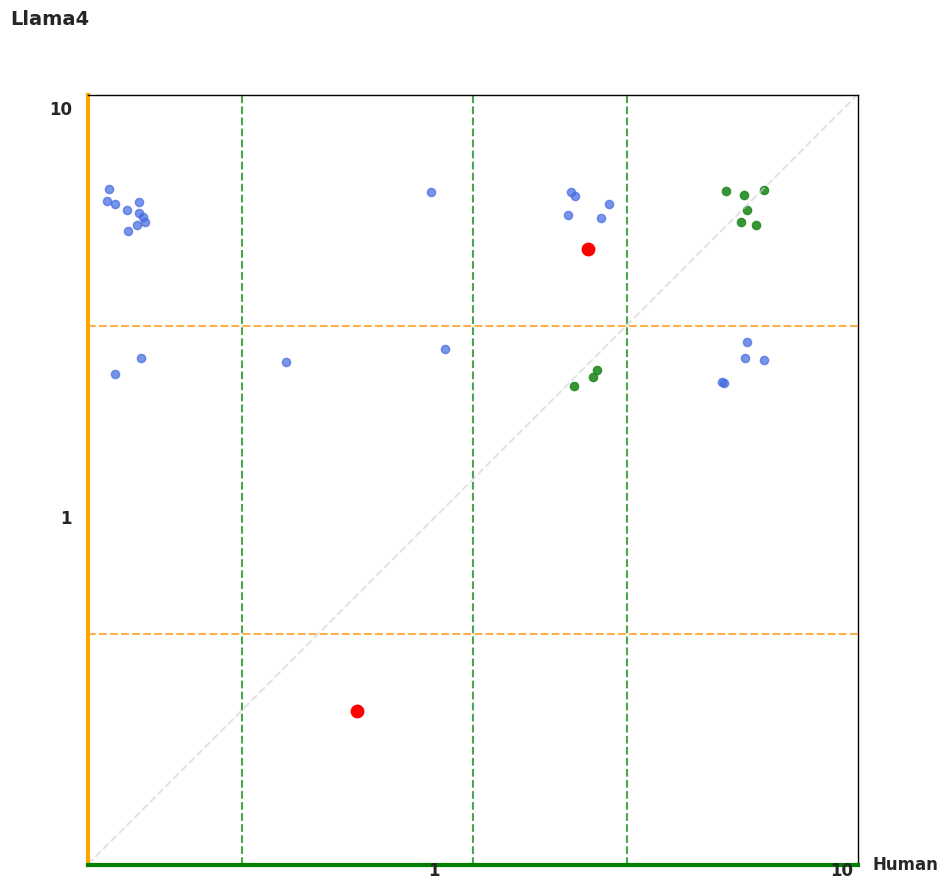

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Load the data
human_data = pd.read_csv("/content/results/human_annotations.csv")
llama_data = pd.read_csv("/content/results/Llama-4-Scout-17B-16E-Instruct-FP8_predictions.csv")

# Merge datasets on the image name
merged_data = pd.merge(human_data, llama_data, on="Image", suffixes=("_human", "_llama"))

# Get all metrics (excluding 'Image')
metrics = [col.replace('_human', '') for col in merged_data.columns if col.endswith('_human')]

# Calculate statistics for each metric
results = []
for metric in metrics:
    # Calculate correlation
    correlation = merged_data[f"{metric}_human"].corr(merged_data[f"{metric}_llama"])

    # Calculate agreement percentage
    agreement_count = sum(merged_data[f"{metric}_human"] == merged_data[f"{metric}_llama"])
    total_count = len(merged_data)
    agreement_percentage = (agreement_count / total_count) * 100

    # Get unique values count
    human_unique = merged_data[f"{metric}_human"].nunique()
    llama_unique = merged_data[f"{metric}_llama"].nunique()

    # Calculate variance as a measure of spread
    human_var = merged_data[f"{metric}_human"].var()
    llama_var = merged_data[f"{metric}_llama"].var()

    # Visualization score (higher is better for visualization)
    viz_score = correlation + (agreement_percentage/100) + (human_unique/6) + (llama_unique/6) + human_var + llama_var

    # Store results
    results.append({
        'Metric': metric,
        'Correlation': correlation,
        'Agreement_Percentage': agreement_percentage,
        'Human_Unique': human_unique,
        'Llama_Unique': llama_unique,
        'Human_Var': human_var,
        'Llama_Var': llama_var,
        'Viz_Score': viz_score
    })

# Convert to DataFrame and sort by visualization score
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Viz_Score', ascending=False)

# Print top 5 metrics for visualization
print("Top 5 metrics for visualization:")
print(results_df[['Metric', 'Correlation', 'Agreement_Percentage', 'Human_Unique', 'Llama_Unique', 'Viz_Score']].head(5))

# Get the best metric
best_metric = results_df.iloc[0]['Metric']
print(f"\nBest metric for visualization: {best_metric}")

# Print distribution for the best metric
print(f"\nDistribution of human {best_metric} scores:")
print(merged_data[f"{best_metric}_human"].value_counts().sort_index())

print(f"\nDistribution of Llama4 {best_metric} scores:")
print(merged_data[f"{best_metric}_llama"].value_counts().sort_index())

# Create visualization for the best metric
metric = best_metric

# Create a new column to identify points where human and AI agree
merged_data['agreement'] = merged_data[f"{metric}_human"] == merged_data[f"{metric}_llama"]

# Create figure with white background
plt.figure(figsize=(10, 10), facecolor='white')

# Set up the axes
ax = plt.gca()
ax.set_aspect('equal')
ax.set_xlim(0.5, 10.5)
ax.set_ylim(0.5, 10.5)

# Create colored frame
ax.spines['bottom'].set_color('green')
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_color('orange')
ax.spines['left'].set_linewidth(3)
ax.spines['top'].set_color('black')
ax.spines['top'].set_linewidth(1)
ax.spines['right'].set_color('black')
ax.spines['right'].set_linewidth(1)

# Add jittering to reveal overlapping points
np.random.seed(42)  # For reproducible results
h_jitter_amount = 0.3
v_jitter_amount = 0.3
x_jitter = np.random.uniform(-h_jitter_amount, h_jitter_amount, size=len(merged_data))
y_jitter = np.random.uniform(-v_jitter_amount, v_jitter_amount, size=len(merged_data))

# Transform from 0-5 scale to 1-10 scale for visualization
x = merged_data[f"{metric}_human"] * 2 + x_jitter + 1
y = merged_data[f"{metric}_llama"] * 2 + y_jitter + 1

# Plot points with different colors for agreement/disagreement
scatter1 = plt.scatter(
    x[~merged_data['agreement']],
    y[~merged_data['agreement']],
    color='royalblue',
    alpha=0.7,
    s=35
)

scatter2 = plt.scatter(
    x[merged_data['agreement']],
    y[merged_data['agreement']],
    color='forestgreen',
    alpha=0.9,
    s=35
)

# Add reference lines matching the example image
plt.axhline(y=7.5, color='darkorange', linestyle='--', alpha=0.7)
plt.axhline(y=3.5, color='darkorange', linestyle='--', alpha=0.7)
plt.axvline(x=2.5, color='green', linestyle='--', alpha=0.7)
plt.axvline(x=5.5, color='green', linestyle='--', alpha=0.7)
plt.axvline(x=7.5, color='green', linestyle='--', alpha=0.7)

# Add diagonal line
diagonal = np.linspace(0.5, 10.5, 100)
plt.plot(diagonal, diagonal, 'lightgray', linestyle='--', alpha=0.6)

# Add example red dots (positioned similarly to the reference image)
plt.scatter([7.0, 4.0], [8.5, 2.5], color='red', s=80, zorder=10)

# Add GPT/Llama4 label at top
plt.figtext(0.05, 0.95, "Llama4", fontsize=14, ha='left', fontweight='bold')

# Add labels
plt.text(10.7, 0.5, "Human", fontsize=12, ha='left', va='center', fontweight='bold')
plt.text(5.0, 0.3, "1", fontsize=12, ha='center', va='bottom', fontweight='bold')
plt.text(10.3, 0.3, "10", fontsize=12, ha='center', va='bottom', fontweight='bold')
plt.text(0.3, 5.0, "1", fontsize=12, ha='right', va='center', fontweight='bold')
plt.text(0.3, 10.3, "10", fontsize=12, ha='right', va='center', fontweight='bold')

# Remove tick labels
plt.xticks([])
plt.yticks([])

# Clean design without grid lines
plt.grid(False)

# Calculate statistics for the selected metric
correlation = merged_data[f"{metric}_human"].corr(merged_data[f"{metric}_llama"])
agreement_count = sum(merged_data['agreement'])
agreement_percentage = (agreement_count / len(merged_data)) * 100

# Print statistics
print(f"\nFinal statistics for {metric}:")
print(f"Correlation: {correlation:.2f}")
print(f"Agreement: {agreement_count}/{len(merged_data)} ({agreement_percentage:.1f}%)")

# Save in vector format for selectable text
plt.savefig(f"human_vs_llama_{metric.lower()}_styled.svg", format='svg', bbox_inches='tight')
plt.savefig(f"human_vs_llama_{metric.lower()}_styled.png", dpi=300, bbox_inches='tight')

plt.show()

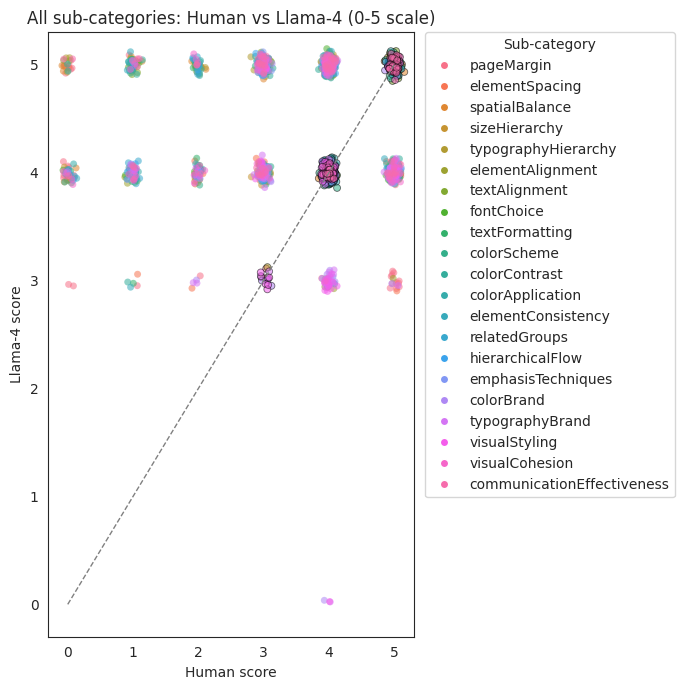

In [ ]:

import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns

human  = pd.read_csv("/content/results/human_annotations.csv")
llama4 = pd.read_csv("/content/results/Llama-4-Scout-17B-16E-Instruct-FP8_predictions.csv")

# columns we want to compare (skip the first “Image” column)
METRICS = human.columns[1:]

# melt → long form then merge
h_long = human.melt(id_vars="Image", value_vars=METRICS,
                    var_name="metric", value_name="human")
l_long = llama4.melt(id_vars="Image", value_vars=METRICS,
                     var_name="metric", value_name="llama")

df = (h_long
      .merge(l_long, on=["Image", "metric"])
      .dropna())

# --- jitter so overlapping dots separate slightly -------------------
rng = np.random.default_rng(0)
df["human_j"]  = df["human"]  + rng.normal(0, .05, len(df))
df["llama_j"]  = df["llama"]  + rng.normal(0, .05, len(df))

# --- plotting -------------------------------------------------------
plt.figure(figsize=(7, 7))
palette = sns.color_palette("husl", n_colors=len(METRICS))
metric2col = dict(zip(METRICS, palette))

for m in METRICS:
    subset = df[df.metric == m]
    plt.scatter(subset.human_j,
                subset.llama_j,
                s        = 25,
                color    = metric2col[m],
                alpha    = .55,
                edgecolor=np.where(subset.human == subset.llama,
                                   "black", "none"),
                linewidth=np.where(subset.human == subset.llama, .6, 0))

# reference diagonal
plt.plot([0,5],[0,5], ls="--", lw=1, color="gray")

plt.xticks(range(0,6)), plt.yticks(range(0,6))
plt.xlim(-.3,5.3),       plt.ylim(-.3,5.3)
plt.xlabel("Human score"), plt.ylabel("Llama-4 score")
plt.title("All sub-categories: Human vs Llama-4 (0-5 scale)")

# tidy legend with one entry per metric
handles = [plt.Line2D([0],[0], marker='o', color='w',
                      markerfacecolor=metric2col[m], markersize=6,
                      label=m) for m in METRICS]
plt.legend(handles=handles, bbox_to_anchor=(1.03,1), loc="upper left",
           title="Sub-category", borderaxespad=0.)

plt.tight_layout()
plt.savefig("scatter_all_metrics.png", dpi=300)
plt.show()


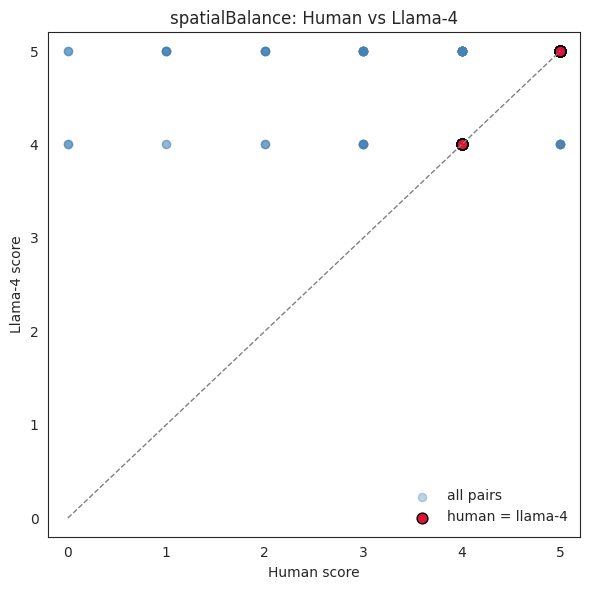

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1) load data  – use the full tables
# ------------------------------------------------------------------
human  = pd.read_csv("/content/results/human_annotations.csv")
llama4 = pd.read_csv("/content/results/Llama-4-Scout-17B-16E-Instruct-FP8_predictions.csv")

# choose the rubric column you want to inspect
COL = "spatialBalance"        # change to any other column (0-5 scale)

# merge on image name
df = (human[["Image", COL]]
      .merge(llama4[["Image", COL]], on="Image",
              suffixes=("_human", "_llama"))
      .dropna())

# ------------------------------------------------------------------
# 2) draw scatter
#    * blue   = every pair of scores
#    * red    = instances where model == human
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 6))

# all pairs – slight transparency so dense regions look darker
ax.scatter(df[f"{COL}_human"],
           df[f"{COL}_llama"],
           s=35, alpha=0.35, color="steelblue", label="all pairs")

# highlight perfect matches
same = df[df[f"{COL}_human"] == df[f"{COL}_llama"]]
ax.scatter(same[f"{COL}_human"], same[f"{COL}_llama"],
           s=60, color="crimson", edgecolor="k",
           label="human = llama-4")

# reference diagonal
ax.plot([0, 5], [0, 5], ls="--", lw=1, color="gray")

# axes & labels
ax.set_xlim(-0.2, 5.2)
ax.set_ylim(-0.2, 5.2)
ax.set_xticks(range(0, 6))
ax.set_yticks(range(0, 6))
ax.set_xlabel("Human score")
ax.set_ylabel("Llama-4 score")
ax.set_title(f"{COL}: Human vs Llama-4")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(f"scatter_{COL}.png", dpi=300)
plt.show()


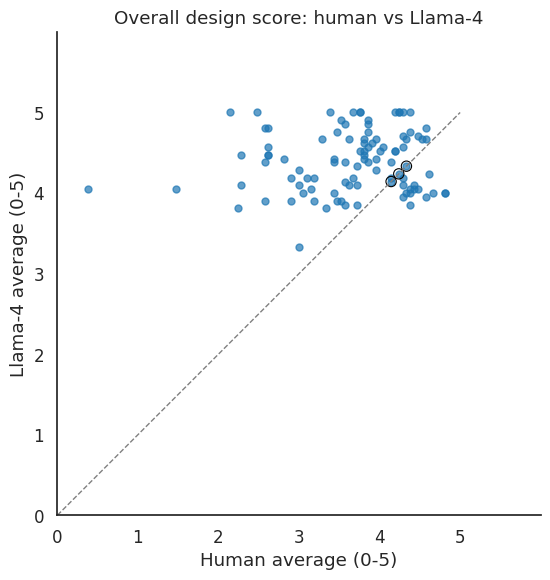

In [ ]:

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

human  = pd.read_csv("/content/results/human_annotations.csv")
llama4 = pd.read_csv("/content/results/Llama-4-Scout-17B-16E-Instruct-FP8_predictions.csv")

# ------------------------------------------------------------------
# 1) Build per-image average (drop the 'Image' column itself)
# ------------------------------------------------------------------
human["mean_score"]  = human.iloc[:, 1:].mean(axis=1)
llama4["mean_score"] = llama4.iloc[:, 1:].mean(axis=1)

df = (human[["Image", "mean_score"]]
      .merge(llama4[["Image", "mean_score"]], on="Image",
             suffixes=("_human", "_llama")))

# ------------------------------------------------------------------
# 2) Scatter plot + reference cues
# ------------------------------------------------------------------
plt.figure(figsize=(6, 6))
sns.set_style("white")

# all dots
plt.scatter(df.mean_score_human,
            df.mean_score_llama,
            s=25, alpha=.7, color="#1f77b4")

# perfect matches = black edge
match = df[np.isclose(df.mean_score_human, df.mean_score_llama)]
plt.scatter(match.mean_score_human,
            match.mean_score_llama,
            s=55, facecolors='none', edgecolors='black', linewidths=0.8)

# diagonal reference
plt.plot([0,5],[0,5], color="gray", ls="--", lw=1)




# labels & limits
plt.xlim(0,6), plt.ylim(0,6)
plt.xticks(range(0,6)), plt.yticks(range(0,6))
plt.xlabel("Human average (0-5)"), plt.ylabel("Llama-4 average (0-5)")
plt.title("Overall design score: human vs Llama-4")

plt.gca().set_aspect("equal", adjustable="box")
sns.despine()
plt.tight_layout()
plt.savefig("overall_human_vs_llama4.png", dpi=300)
plt.show()


In [ ]:
def reexport_mae_plot_from_json(json_path, output_dir="/content/results/visualizations"):
    """
    Reexport MAE plot from JSON file in PDF and SVG formats with selectable text

    Args:
        json_path: Path to the MAE JSON file
        output_dir: Directory to save the output files
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    # Load MAE data from JSON file
    with open(json_path, 'r') as f:
        mae_results = json.load(f)

    # Extract model name from the JSON filename
    filename = os.path.basename(json_path)
    model_name = filename.replace('_mae.json', '').replace('_mae_results.json', '')

    print(f"Creating plots for {model_name}...")

    # Configure plot for selectable text
    plt.rcParams['svg.fonttype'] = 'none'  # Ensures text is saved as text, not paths

    # Create figure
    plt.figure(figsize=(16, 8))

    # Prepare data
    subcategory_mae = mae_results.get("subcategory_mae", {})

    # Sort by MAE value
    sorted_subcats = sorted(subcategory_mae.items(), key=lambda x: x[1])
    subcat_names = [item[0] for item in sorted_subcats]
    subcat_values = [item[1] for item in sorted_subcats]

    # Create the horizontal bar plot
    ax = sns.barplot(x=subcat_names, y=subcat_values)

    # Add value labels to the bars
    for i, v in enumerate(subcat_values):
        ax.text(i, v + 0.02, f"{v:.2f}", ha='center')

    # Add overall MAE line
    overall_mae = mae_results.get("overall_mae", 0)
    plt.axhline(y=overall_mae, color='r', linestyle='--',
                label=f"Overall MAE: {overall_mae:.2f}")
    plt.legend(loc='upper left')

    # Style the plot
    plt.title(f"Mean Absolute Error by Subcategory: {model_name}")
    plt.ylabel("MAE (lower is better)")
    plt.xlabel("Subcategory")

    # Adjust layout
    plt.xticks(rotation=90)
    plt.ylim(0, max(subcat_values) * 1.1)  # Add some space for the labels
    plt.tight_layout()

    # Save as SVG for selectable text
    svg_path = os.path.join(output_dir, f"{model_name}_subcategory_mae.svg")
    plt.savefig(svg_path, format='svg', bbox_inches='tight')

    # Save as PDF
    pdf_path = os.path.join(output_dir, f"{model_name}_subcategory_mae.pdf")
    plt.savefig(pdf_path, format='pdf', bbox_inches='tight')

    plt.close()
    print(f"Saved plots to:")
    print(f"  - SVG: {svg_path}")
    print(f"  - PDF: {pdf_path}")

# List of MAE JSON files to process
mae_json_files = [
    "/content/results/Qwen2.5-VL-7B-Instruct-unsloth-bnb-4bit_mae.json",
    "/content/results/Llama-4-Scout-17B-16E-Instruct-FP8_mae_results.json",
    "/content/results/llama3-pipeline_mae.json",
    "/content/results/gemma-3-12b-it-unsloth-bnb-4bit_mae.json",
    "/content/results/internvl3-14b_mae.json"
]

# Process each JSON file
for json_file in mae_json_files:
    if os.path.exists(json_file):
        reexport_mae_plot_from_json(json_file)
    else:
        print(f"File not found: {json_file}")

Creating plots for Qwen2.5-VL-7B-Instruct-unsloth-bnb-4bit...
Saved plots to:
  - SVG: /content/results/visualizations/Qwen2.5-VL-7B-Instruct-unsloth-bnb-4bit_subcategory_mae.svg
  - PDF: /content/results/visualizations/Qwen2.5-VL-7B-Instruct-unsloth-bnb-4bit_subcategory_mae.pdf
Creating plots for Llama-4-Scout-17B-16E-Instruct-FP8...
Saved plots to:
  - SVG: /content/results/visualizations/Llama-4-Scout-17B-16E-Instruct-FP8_subcategory_mae.svg
  - PDF: /content/results/visualizations/Llama-4-Scout-17B-16E-Instruct-FP8_subcategory_mae.pdf
Creating plots for llama3-pipeline...
Saved plots to:
  - SVG: /content/results/visualizations/llama3-pipeline_subcategory_mae.svg
  - PDF: /content/results/visualizations/llama3-pipeline_subcategory_mae.pdf
Creating plots for gemma-3-12b-it-unsloth-bnb-4bit...
Saved plots to:
  - SVG: /content/results/visualizations/gemma-3-12b-it-unsloth-bnb-4bit_subcategory_mae.svg
  - PDF: /content/results/visualizations/gemma-3-12b-it-unsloth-bnb-4bit_subcategory